In [ ]:
# Case 3A — Plasma–Mechanical Dimensionless Comparison

Case 3A compares two physically distinct engineering systems:

1. a magnetically filtered plasma represented by a validated coupled-state
   modal eigenstructure;

2. a magnetically actuated structural mode represented by conventional
   modal mechanics.

Their dimensional characteristic frequencies differ by approximately three
orders of magnitude, and their microscopic physics are unrelated.

The comparison is performed only after normalization.

For each system,

\[
\Omega=\frac{\omega}{\omega_n}.
\]

The modal-equivalent response is

\[
\mathcal{H}(\Omega,\zeta)
=
\frac{1}{
\sqrt{
(1-\Omega^2)^2
+
(2\zeta\Omega)^2
}
}.
\]

Case 1D identified

\[
\zeta_p \approx 0.780,
\]

while Case 2B deliberately retained the mechanical condition

\[
\zeta_m=0.78.
\]

Case 3A tests:

- response-space distance between the damping-matched systems;
- response-space distance before damping matching;
- parameter-space distance;
- the relationship between parameter-space and response-space similarity.

No microscopic physical equivalence is implied.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Locked values from completed evidence packages
# --------------------------------------------------

# Case 1D plasma
FN_P_HZ = 431479.5832547581
FN_P_STD_HZ = 39102.033891887135

ZETA_P = 0.7800088823828552
ZETA_P_STD = 0.030895691295456208

# Case 2 mechanical
FN_M_HZ = 327.195972
ZETA_M_BASE = 0.02

# Deliberately matched Case 2B condition
ZETA_M_MATCH = 0.78

print(
    f"Plasma: fn={FN_P_HZ/1e3:.2f} kHz, "
    f"zeta={ZETA_P:.4f}"
)

print(
    f"Mechanical: fn={FN_M_HZ:.3f} Hz, "
    f"baseline zeta={ZETA_M_BASE:.3f}, "
    f"matched zeta={ZETA_M_MATCH:.3f}"
)

print(
    "Frequency-scale ratio fn,p/fn,m =",
    FN_P_HZ/FN_M_HZ
)

Plasma: fn=431.48 kHz, zeta=0.7800
Mechanical: fn=327.196 Hz, baseline zeta=0.020, matched zeta=0.780
Frequency-scale ratio fn,p/fn,m = 1318.7191169173627


In [2]:
def H_normalized(Omega, zeta):

    Omega = np.asarray(
        Omega,
        dtype=float
    )

    return (
        1.0
        /
        np.sqrt(
            (
                1.0
                -
                Omega**2
            )**2
            +
            (
                2.0
                *
                zeta
                *
                Omega
            )**2
        )
    )


def phase_normalized(Omega, zeta):

    Omega = np.asarray(
        Omega,
        dtype=float
    )

    return -np.arctan2(
        2.0*zeta*Omega,
        1.0-Omega**2
    )

In [3]:
OMEGA_COMMON = np.linspace(
    0.0,
    2.5,
    1001
)

H_PLASMA = H_normalized(
    OMEGA_COMMON,
    ZETA_P
)

H_MECH_MATCH = H_normalized(
    OMEGA_COMMON,
    ZETA_M_MATCH
)

H_MECH_BASE = H_normalized(
    OMEGA_COMMON,
    ZETA_M_BASE
)

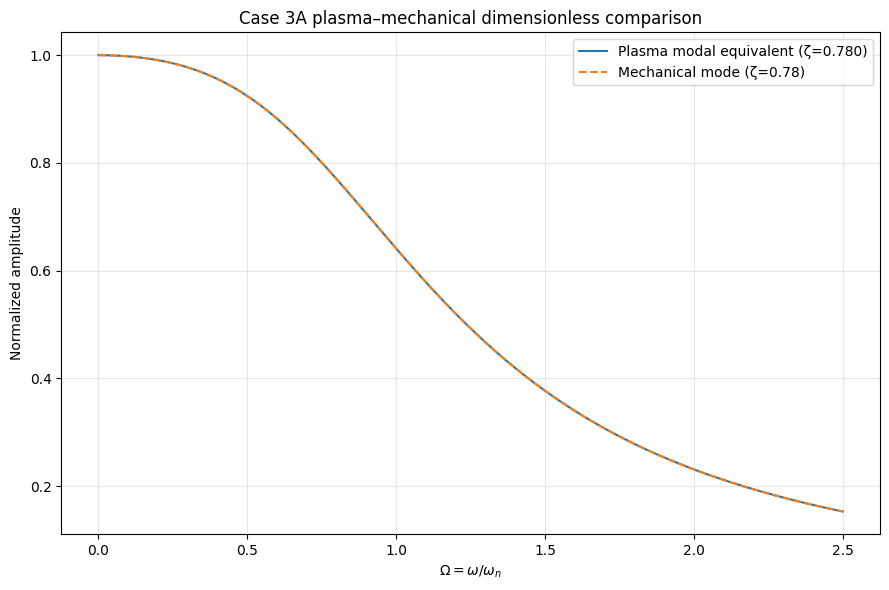

In [4]:
plt.figure(
    figsize=(9,6)
)

plt.plot(
    OMEGA_COMMON,
    H_PLASMA,
    label=(
        f"Plasma modal equivalent "
        f"(ζ={ZETA_P:.3f})"
    )
)

plt.plot(
    OMEGA_COMMON,
    H_MECH_MATCH,
    "--",
    label=(
        f"Mechanical mode "
        f"(ζ={ZETA_M_MATCH:.2f})"
    )
)

plt.xlabel(
    r"$\Omega=\omega/\omega_n$"
)

plt.ylabel(
    "Normalized amplitude"
)

plt.title(
    "Case 3A plasma–mechanical "
    "dimensionless comparison"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()

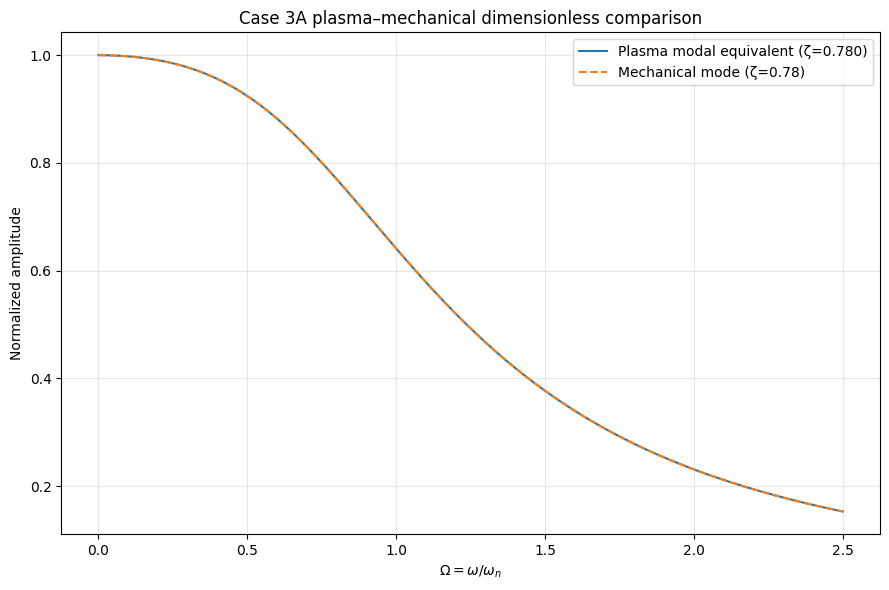

In [5]:
plt.figure(
    figsize=(9,6)
)

plt.plot(
    OMEGA_COMMON,
    H_PLASMA,
    label=(
        f"Plasma modal equivalent "
        f"(ζ={ZETA_P:.3f})"
    )
)

plt.plot(
    OMEGA_COMMON,
    H_MECH_MATCH,
    "--",
    label=(
        f"Mechanical mode "
        f"(ζ={ZETA_M_MATCH:.2f})"
    )
)

plt.xlabel(
    r"$\Omega=\omega/\omega_n$"
)

plt.ylabel(
    "Normalized amplitude"
)

plt.title(
    "Case 3A plasma–mechanical "
    "dimensionless comparison"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()

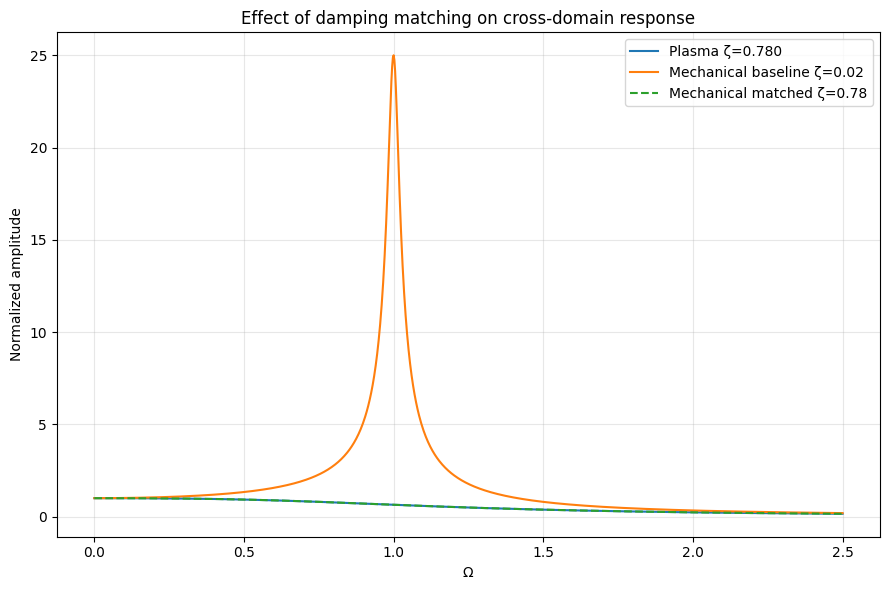

In [6]:
plt.figure(
    figsize=(9,6)
)

plt.plot(
    OMEGA_COMMON,
    H_PLASMA,
    label=(
        f"Plasma ζ={ZETA_P:.3f}"
    )
)

plt.plot(
    OMEGA_COMMON,
    H_MECH_BASE,
    label=(
        f"Mechanical baseline "
        f"ζ={ZETA_M_BASE:.2f}"
    )
)

plt.plot(
    OMEGA_COMMON,
    H_MECH_MATCH,
    "--",
    label=(
        f"Mechanical matched "
        f"ζ={ZETA_M_MATCH:.2f}"
    )
)

plt.xlabel(
    r"$\Omega$"
)

plt.ylabel(
    "Normalized amplitude"
)

plt.title(
    "Effect of damping matching "
    "on cross-domain response"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()

In [7]:
def response_distance(
    H1,
    H2
):

    H1 = np.asarray(H1)
    H2 = np.asarray(H2)

    return np.sqrt(
        np.mean(
            (
                H1
                -
                H2
            )**2
        )
    )


D_PM_MATCH = response_distance(
    H_PLASMA,
    H_MECH_MATCH
)

D_PM_BASE = response_distance(
    H_PLASMA,
    H_MECH_BASE
)


print(
    "Matched plasma-mechanical "
    "response distance:",
    D_PM_MATCH
)

print(
    "Baseline plasma-mechanical "
    "response distance:",
    D_PM_BASE
)

print(
    "Distance reduction factor:",
    D_PM_BASE
    /
    max(
        D_PM_MATCH,
        1e-15
    )
)

Matched plasma-mechanical response distance: 4.416793220759986e-06
Baseline plasma-mechanical response distance: 3.6751935301869323
Distance reduction factor: 832095.4471929187


In [8]:
def relative_response_distance(
    H_ref,
    H_test
):

    numerator = np.linalg.norm(
        H_ref
        -
        H_test
    )

    denominator = np.linalg.norm(
        H_ref
    )

    return (
        numerator
        /
        denominator
    )


DREL_PM_MATCH = (
    relative_response_distance(
        H_PLASMA,
        H_MECH_MATCH
    )
)

DREL_PM_BASE = (
    relative_response_distance(
        H_PLASMA,
        H_MECH_BASE
    )
)


print(
    "Relative matched distance:",
    DREL_PM_MATCH
)

print(
    "Relative baseline distance:",
    DREL_PM_BASE
)

Relative matched distance: 7.029680941147546e-06
Relative baseline distance: 5.849365506347706


In [9]:
DPI_MATCH = abs(
    ZETA_P
    -
    ZETA_M_MATCH
)

DPI_BASE = abs(
    ZETA_P
    -
    ZETA_M_BASE
)


print(
    "Matched shared-parameter "
    "distance:",
    DPI_MATCH
)

print(
    "Baseline shared-parameter "
    "distance:",
    DPI_BASE
)

Matched shared-parameter distance: 8.882382855124327e-06
Baseline shared-parameter distance: 0.7600088823828551


In [10]:
ZETA_COMPARE = np.array([
    0.02,
    0.05,
    0.10,
    0.30,
    0.50,
    0.78
])

comparison_rows = []

for zeta_m in ZETA_COMPARE:

    H_m = H_normalized(
        OMEGA_COMMON,
        zeta_m
    )

    D_pi = abs(
        ZETA_P
        -
        zeta_m
    )

    D_resp = response_distance(
        H_PLASMA,
        H_m
    )

    D_rel = (
        relative_response_distance(
            H_PLASMA,
            H_m
        )
    )

    comparison_rows.append({

        "zeta_plasma":
            ZETA_P,

        "zeta_mechanical":
            zeta_m,

        "D_parameter":
            D_pi,

        "D_response":
            D_resp,

        "D_response_relative":
            D_rel
    })


case3a_comparison = pd.DataFrame(
    comparison_rows
)

case3a_comparison

,zeta_plasma,zeta_mechanical,D_parameter,D_response,D_response_relative
0,0.780009,0.02,0.760009,3.675194,5.849366
1,0.780009,0.05,0.730009,2.135367,3.398608
2,0.780009,0.10,0.680009,1.331509,2.119203
3,0.780009,0.30,0.480009,0.470314,0.748542
4,0.780009,0.50,0.280009,0.192823,0.306893
5,0.780009,0.78,0.000009,0.000004,0.000007


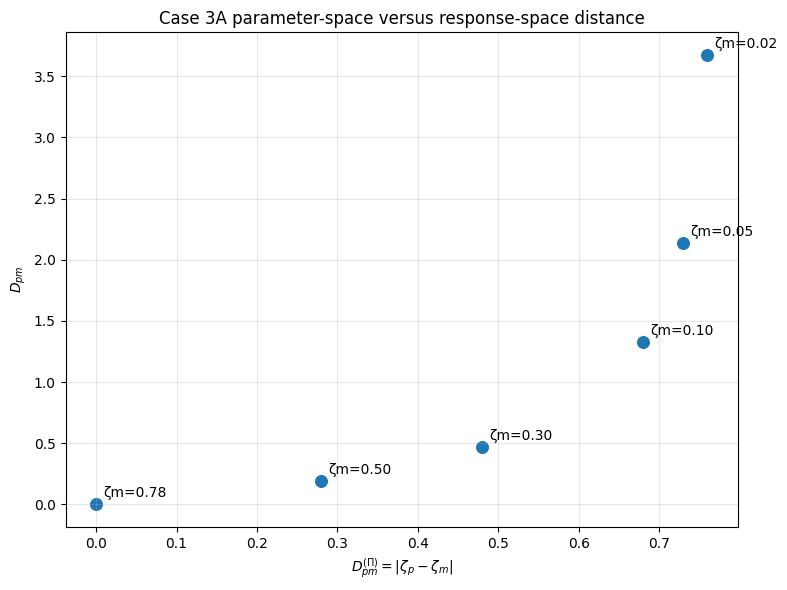

In [11]:
plt.figure(
    figsize=(8,6)
)

plt.scatter(
    case3a_comparison[
        "D_parameter"
    ],
    case3a_comparison[
        "D_response"
    ],
    s=70
)

for _, row in (
    case3a_comparison
    .iterrows()
):

    plt.annotate(
        f"ζm={row['zeta_mechanical']:.2f}",
        (
            row[
                "D_parameter"
            ],
            row[
                "D_response"
            ]
        ),
        xytext=(5,5),
        textcoords="offset points"
    )

plt.xlabel(
    r"$D_{pm}^{(\Pi)}=|\zeta_p-\zeta_m|$"
)

plt.ylabel(
    r"$D_{pm}$"
)

plt.title(
    "Case 3A parameter-space versus "
    "response-space distance"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [12]:
from scipy.stats import (
    pearsonr,
    spearmanr
)

pearson = pearsonr(
    case3a_comparison[
        "D_parameter"
    ],
    case3a_comparison[
        "D_response"
    ]
)

spearman = spearmanr(
    case3a_comparison[
        "D_parameter"
    ],
    case3a_comparison[
        "D_response"
    ]
)


print(
    "Pearson r =",
    pearson.statistic
)

print(
    "Pearson p =",
    pearson.pvalue
)

print(
    "Spearman rho =",
    spearman.statistic
)

print(
    "Spearman p =",
    spearman.pvalue
)

Pearson r = 0.8149138676285363
Pearson p = 0.048215078214687984
Spearman rho = 1.0
Spearman p = 0.0


In [13]:
x = (
    case3a_comparison[
        "D_parameter"
    ].to_numpy()
)

y = (
    case3a_comparison[
        "D_response"
    ].to_numpy()
)

coef = np.polyfit(
    x,
    y,
    1
)

y_fit = np.polyval(
    coef,
    x
)

ss_res = np.sum(
    (
        y-y_fit
    )**2
)

ss_tot = np.sum(
    (
        y-y.mean()
    )**2
)

R2 = (
    1
    -
    ss_res/ss_tot
)


print(
    "Descriptive slope:",
    coef[0]
)

print(
    "Intercept:",
    coef[1]
)

print(
    "R^2:",
    R2
)

Descriptive slope: 3.8271266300878275
Intercept: -0.5680790414739495
R^2: 0.6640846116532998


In [14]:
scale_table = pd.DataFrame([
    {
        "system":
            "Plasma modal state",

        "fn_Hz":
            FN_P_HZ,

        "zeta":
            ZETA_P
    },

    {
        "system":
            "Mechanical mode",

        "fn_Hz":
            FN_M_HZ,

        "zeta":
            ZETA_M_MATCH
    }
])

scale_table

,system,fn_Hz,zeta
0,Plasma modal state,431479.583255,0.780009
1,Mechanical mode,327.195972,0.780000


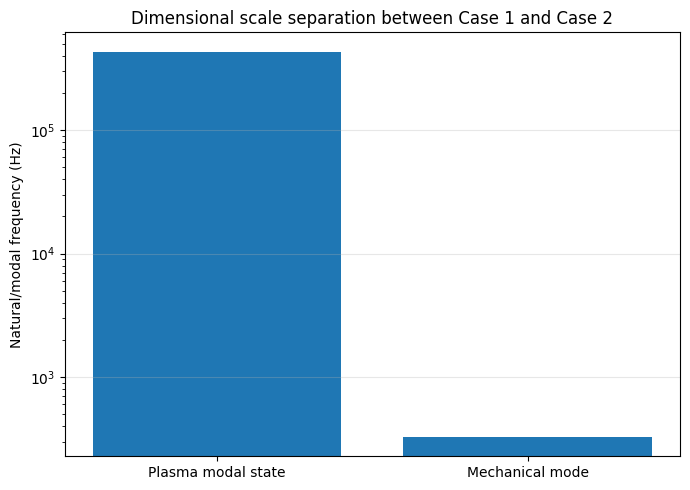

In [15]:
plt.figure(
    figsize=(7,5)
)

plt.bar(
    scale_table["system"],
    scale_table["fn_Hz"]
)

plt.yscale(
    "log"
)

plt.ylabel(
    "Natural/modal frequency (Hz)"
)

plt.title(
    "Dimensional scale separation "
    "between Case 1 and Case 2"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

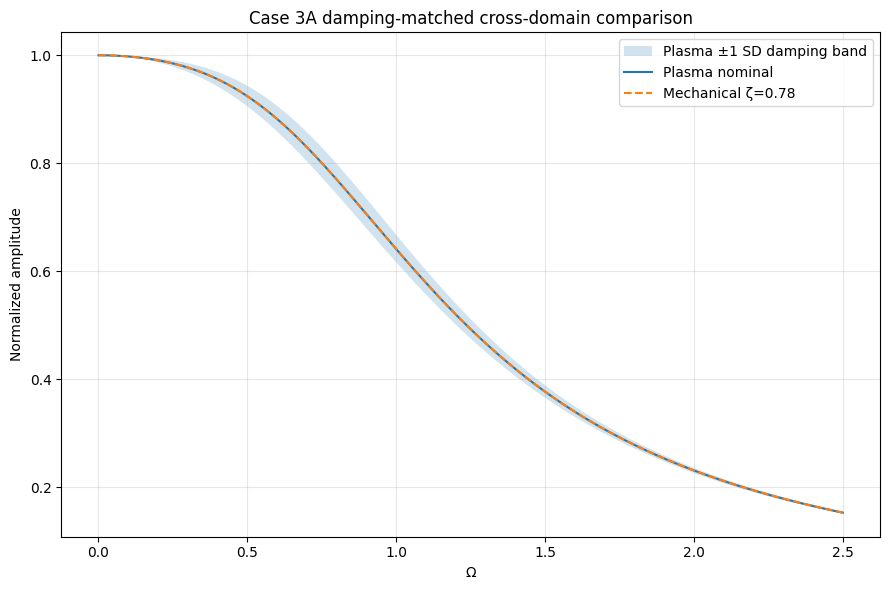

In [16]:
ZETA_P_LOW = (
    ZETA_P
    -
    ZETA_P_STD
)

ZETA_P_HIGH = (
    ZETA_P
    +
    ZETA_P_STD
)

H_P_LOW = H_normalized(
    OMEGA_COMMON,
    ZETA_P_LOW
)

H_P_HIGH = H_normalized(
    OMEGA_COMMON,
    ZETA_P_HIGH
)

H_band_min = np.minimum(
    H_P_LOW,
    H_P_HIGH
)

H_band_max = np.maximum(
    H_P_LOW,
    H_P_HIGH
)


plt.figure(
    figsize=(9,6)
)

plt.fill_between(
    OMEGA_COMMON,
    H_band_min,
    H_band_max,
    alpha=0.2,
    label="Plasma ±1 SD damping band"
)

plt.plot(
    OMEGA_COMMON,
    H_PLASMA,
    label="Plasma nominal"
)

plt.plot(
    OMEGA_COMMON,
    H_MECH_MATCH,
    "--",
    label="Mechanical ζ=0.78"
)

plt.xlabel(
    r"$\Omega$"
)

plt.ylabel(
    "Normalized amplitude"
)

plt.title(
    "Case 3A damping-matched "
    "cross-domain comparison"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()

In [17]:
D_LOW = response_distance(
    H_P_LOW,
    H_MECH_MATCH
)

D_NOM = response_distance(
    H_PLASMA,
    H_MECH_MATCH
)

D_HIGH = response_distance(
    H_P_HIGH,
    H_MECH_MATCH
)


print(
    "Matched response distance:"
)

print(
    "  Plasma zeta low:",
    D_LOW
)

print(
    "  Plasma nominal:",
    D_NOM
)

print(
    "  Plasma zeta high:",
    D_HIGH
)

Matched response distance:
  Plasma zeta low: 0.015831641053799493
  Plasma nominal: 4.416793220759986e-06
  Plasma zeta high: 0.01492366245349327


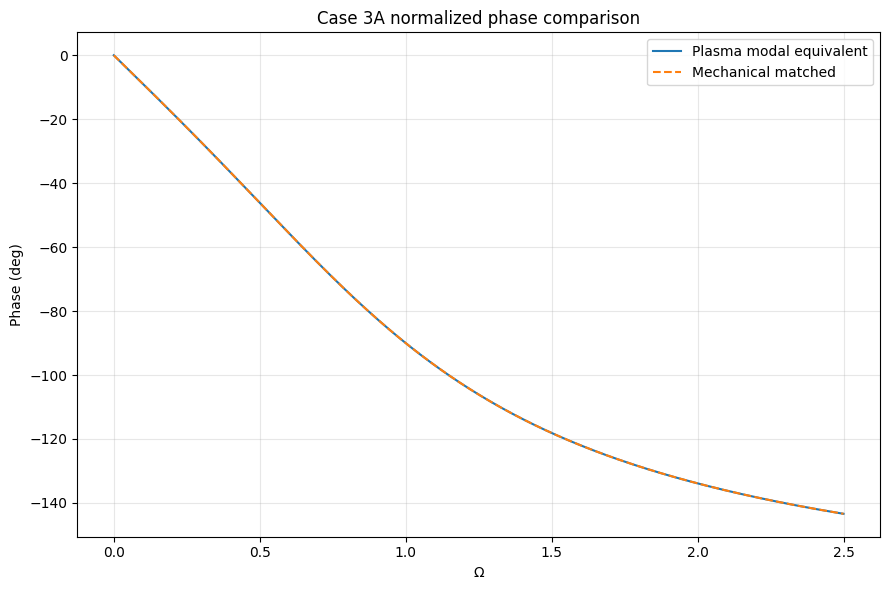

In [18]:
PHASE_P = phase_normalized(
    OMEGA_COMMON,
    ZETA_P
)

PHASE_M = phase_normalized(
    OMEGA_COMMON,
    ZETA_M_MATCH
)


plt.figure(
    figsize=(9,6)
)

plt.plot(
    OMEGA_COMMON,
    PHASE_P*180/np.pi,
    label="Plasma modal equivalent"
)

plt.plot(
    OMEGA_COMMON,
    PHASE_M*180/np.pi,
    "--",
    label="Mechanical matched"
)

plt.xlabel(
    r"$\Omega$"
)

plt.ylabel(
    "Phase (deg)"
)

plt.title(
    "Case 3A normalized phase comparison"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()

In [19]:
D_PHASE = np.sqrt(
    np.mean(
        (
            PHASE_P
            -
            PHASE_M
        )**2
    )
)

print(
    "RMS phase distance (rad):",
    D_PHASE
)

print(
    "RMS phase distance (deg):",
    D_PHASE*180/np.pi
)

RMS phase distance (rad): 4.5092604478625095e-06
RMS phase distance (deg): 0.0002583615923877932


In [20]:
print("CASE 3A SUMMARY")
print("--------------------------------")

print(
    f"Dimensional frequency ratio "
    f"fn,p/fn,m = "
    f"{FN_P_HZ/FN_M_HZ:.1f}"
)

print(
    f"\nPlasma zeta = "
    f"{ZETA_P:.4f} ± "
    f"{ZETA_P_STD:.4f}"
)

print(
    f"Mechanical baseline zeta = "
    f"{ZETA_M_BASE:.4f}"
)

print(
    f"Mechanical matched zeta = "
    f"{ZETA_M_MATCH:.4f}"
)

print(
    "\nMatched parameter distance:",
    DPI_MATCH
)

print(
    "Baseline parameter distance:",
    DPI_BASE
)

print(
    "\nMatched response distance:",
    D_PM_MATCH
)

print(
    "Baseline response distance:",
    D_PM_BASE
)

print(
    "\nRelative matched response distance:",
    DREL_PM_MATCH
)

print(
    "Relative baseline response distance:",
    DREL_PM_BASE
)

print(
    "\nPearson r:",
    pearson.statistic
)

print(
    "Spearman rho:",
    spearman.statistic
)

print(
    "Descriptive R^2:",
    R2
)

print(
    "\nMatched phase RMS distance (deg):",
    D_PHASE*180/np.pi
)

CASE 3A SUMMARY
--------------------------------
Dimensional frequency ratio fn,p/fn,m = 1318.7

Plasma zeta = 0.7800 ± 0.0309
Mechanical baseline zeta = 0.0200
Mechanical matched zeta = 0.7800

Matched parameter distance: 8.882382855124327e-06
Baseline parameter distance: 0.7600088823828551

Matched response distance: 4.416793220759986e-06
Baseline response distance: 3.6751935301869323

Relative matched response distance: 7.029680941147546e-06
Relative baseline response distance: 5.849365506347706

Pearson r: 0.8149138676285363
Spearman rho: 1.0
Descriptive R^2: 0.6640846116532998

Matched phase RMS distance (deg): 0.0002583615923877932


In [21]:
from pathlib import Path
import json

OUT3 = Path(
    "mea_case3_outputs"
)

OUT3.mkdir(
    exist_ok=True
)


case3a_comparison.to_csv(
    OUT3
    /
    "case3a_parameter_response_distance.csv",
    index=False
)

case3a_curves = pd.DataFrame({
    "Omega":
        OMEGA_COMMON,

    "H_plasma":
        H_PLASMA,

    "H_mechanical_baseline":
        H_MECH_BASE,

    "H_mechanical_matched":
        H_MECH_MATCH,

    "phase_plasma_rad":
        PHASE_P,

    "phase_mechanical_matched_rad":
        PHASE_M
})

case3a_curves.to_csv(
    OUT3
    /
    "case3a_cross_domain_curves.csv",
    index=False
)


case3a_summary = {

    "plasma": {
        "fn_Hz":
            FN_P_HZ,

        "fn_std_Hz":
            FN_P_STD_HZ,

        "zeta":
            ZETA_P,

        "zeta_std":
            ZETA_P_STD
    },

    "mechanical": {
        "fn_Hz":
            FN_M_HZ,

        "zeta_baseline":
            ZETA_M_BASE,

        "zeta_matched":
            ZETA_M_MATCH
    },

    "dimensional_frequency_ratio":
        float(
            FN_P_HZ/FN_M_HZ
        ),

    "parameter_distance": {
        "matched":
            float(DPI_MATCH),

        "baseline":
            float(DPI_BASE)
    },

    "response_distance": {
        "matched":
            float(D_PM_MATCH),

        "baseline":
            float(D_PM_BASE),

        "relative_matched":
            float(DREL_PM_MATCH),

        "relative_baseline":
            float(DREL_PM_BASE),

        "matched_zeta_low":
            float(D_LOW),

        "matched_zeta_high":
            float(D_HIGH)
    },

    "phase_distance_deg":
        float(
            D_PHASE*180/np.pi
        ),

    "parameter_response_association": {
        "pearson_r":
            float(
                pearson.statistic
            ),

        "pearson_p":
            float(
                pearson.pvalue
            ),

        "spearman_rho":
            float(
                spearman.statistic
            ),

        "spearman_p":
            float(
                spearman.pvalue
            ),

        "descriptive_R2":
            float(R2)
    },

    "interpretation":
        (
            "Physically distinct plasma and "
            "mechanical systems exhibit nearly "
            "identical modal-equivalent normalized "
            "responses when the shared damping "
            "coordinate is matched. This demonstrates "
            "reduced mathematical similarity only; "
            "it does not imply microscopic physical "
            "equivalence."
        )
}


with open(
    OUT3
    /
    "case3a_summary.json",
    "w"
) as f:

    json.dump(
        case3a_summary,
        f,
        indent=2
    )


print(
    "Case 3A evidence exported to:",
    OUT3.resolve()
)

Case 3A evidence exported to: /content/mea_case3_outputs


In [22]:
# Case 3B — Robustness of the Parameter-Space / Response-Space Relationship

Case 3A demonstrated that the normalized plasma modal response and mechanical
modal response become nearly identical when their shared damping coordinate
is matched.

Case 3B tests whether this result is robust rather than dependent on one
nominal matched point.

Three independent variations are introduced:

### Plasma damping uncertainty

\[
\zeta_p
\in
\{
\mu_{\zeta_p}-\sigma_{\zeta_p},
\mu_{\zeta_p},
\mu_{\zeta_p}+\sigma_{\zeta_p}
\}.
\]

### Mechanical magnetic-stiffness coupling

\[
\Pi_{C,m}
\in
\{-0.10,-0.05,0,0.05,0.10\}.
\]

### Mechanical damping

\[
\zeta_m
\in
\{0.02,0.05,0.10,0.30,0.50,0.78\}.
\]

For each combination, the mechanical natural frequency is

\[
\omega_{n,m}(\Pi_{C,m})
=
\omega_{n,m,0}
\sqrt{1+\Pi_{C,m}}.
\]

Each response is then expressed using its own local normalized frequency,

\[
\Omega
=
\frac{\omega}{\omega_n}.
\]

The primary hypothesis is:

\[
|\zeta_p-\zeta_m|\downarrow
\quad\Longrightarrow\quad
D_{pm}\downarrow,
\]

while the normalized response should remain approximately invariant to
\(\Pi_{C,m}\) after local frequency normalization.

No equivalence between the plasma magnetization parameter and mechanical
stiffness-coupling parameter is assumed.

SyntaxError: invalid decimal literal (4113459382.py, line 3)

In [23]:
# Locked Case 1D values
ZETA_P_MEAN = 0.7800088823828552
ZETA_P_STD = 0.030895691295456208

# Locked Case 2 values
FN_M0_HZ = 327.195972

ZETA_M_GRID = np.array([
    0.02,
    0.05,
    0.10,
    0.30,
    0.50,
    0.78
])

PIC_M_GRID = np.array([
    -0.10,
    -0.05,
     0.00,
     0.05,
     0.10
])

ZETA_P_GRID = np.array([
    ZETA_P_MEAN - ZETA_P_STD,
    ZETA_P_MEAN,
    ZETA_P_MEAN + ZETA_P_STD
])

print(
    "Plasma damping grid:",
    ZETA_P_GRID
)

print(
    "Mechanical damping grid:",
    ZETA_M_GRID
)

print(
    "Mechanical coupling grid:",
    PIC_M_GRID
)

print(
    "Total comparisons:",
    len(ZETA_P_GRID)
    *
    len(ZETA_M_GRID)
    *
    len(PIC_M_GRID)
)

Plasma damping grid: [0.74911319 0.78000888 0.81090457]
Mechanical damping grid: [0.02 0.05 0.1  0.3  0.5  0.78]
Mechanical coupling grid: [-0.1  -0.05  0.    0.05  0.1 ]
Total comparisons: 90


In [24]:
OMEGA_3B = np.linspace(
    0.0,
    2.5,
    1001
)


def H3B(Omega, zeta):

    return (
        1.0
        /
        np.sqrt(
            (
                1.0
                -
                Omega**2
            )**2
            +
            (
                2*zeta*Omega
            )**2
        )
    )


def D_response(H1, H2):

    return np.sqrt(
        np.mean(
            (
                H1-H2
            )**2
        )
    )


def D_response_relative(
    H1,
    H2
):

    return (
        np.linalg.norm(
            H1-H2
        )
        /
        np.linalg.norm(
            H1
        )
    )

In [25]:
case3b_rows = []

for zeta_p in ZETA_P_GRID:

    H_p = H3B(
        OMEGA_3B,
        zeta_p
    )

    for PiC_m in PIC_M_GRID:

        fn_m_local = (
            FN_M0_HZ
            *
            np.sqrt(
                1.0
                +
                PiC_m
            )
        )

        for zeta_m in ZETA_M_GRID:

            H_m = H3B(
                OMEGA_3B,
                zeta_m
            )

            D_pi = abs(
                zeta_p
                -
                zeta_m
            )

            D_resp = D_response(
                H_p,
                H_m
            )

            D_rel = (
                D_response_relative(
                    H_p,
                    H_m
                )
            )

            case3b_rows.append({

                "zeta_p":
                    zeta_p,

                "zeta_m":
                    zeta_m,

                "Pi_C_m":
                    PiC_m,

                "fn_m_local_Hz":
                    fn_m_local,

                "D_parameter":
                    D_pi,

                "D_response":
                    D_resp,

                "D_response_relative":
                    D_rel
            })


case3b = pd.DataFrame(
    case3b_rows
)

case3b.head()

,zeta_p,zeta_m,Pi_C_m,fn_m_local_Hz,D_parameter,D_response,D_response_relative
0,0.749113,0.02,-0.1,310.405354,0.729113,3.665854,5.716574
1,0.749113,0.05,-0.1,310.405354,0.699113,2.123780,3.311846
2,0.749113,0.10,-0.1,310.405354,0.649113,1.318265,2.055718
3,0.749113,0.30,-0.1,310.405354,0.449113,0.455058,0.709623
4,0.749113,0.50,-0.1,310.405354,0.249113,0.177103,0.276176


In [26]:
coupling_spread_rows = []

grouped = case3b.groupby([
    "zeta_p",
    "zeta_m"
])

for (
    zeta_p,
    zeta_m
), d in grouped:

    coupling_spread_rows.append({

        "zeta_p":
            zeta_p,

        "zeta_m":
            zeta_m,

        "D_response_min":
            d[
                "D_response"
            ].min(),

        "D_response_max":
            d[
                "D_response"
            ].max(),

        "D_response_spread":
            (
                d[
                    "D_response"
                ].max()
                -
                d[
                    "D_response"
                ].min()
            )
    })


coupling_spread = pd.DataFrame(
    coupling_spread_rows
)

coupling_spread

,zeta_p,zeta_m,D_response_min,D_response_max,D_response_spread
0,0.749113,0.02,3.665854,3.665854,0.0
1,0.749113,0.05,2.123780,2.123780,0.0
2,0.749113,0.10,1.318265,1.318265,0.0
3,0.749113,0.30,0.455058,0.455058,0.0
4,0.749113,0.50,0.177103,0.177103,0.0
5,0.749113,0.78,0.015832,0.015832,0.0
6,0.780009,0.02,3.675194,3.675194,0.0
7,0.780009,0.05,2.135367,2.135367,0.0
8,0.780009,0.10,1.331509,1.331509,0.0
9,0.780009,0.30,0.470314,0.470314,0.0


In [27]:
MAX_COUPLING_SPREAD = (
    coupling_spread[
        "D_response_spread"
    ].max()
)

print(
    "Maximum response-distance spread "
    "caused by Pi_C,m after local normalization:"
)

print(
    MAX_COUPLING_SPREAD
)

Maximum response-distance spread caused by Pi_C,m after local normalization:
0.0


In [28]:
case3b_unique = (
    case3b
    .groupby(
        [
            "zeta_p",
            "zeta_m"
        ],
        as_index=False
    )
    .agg({

        "D_parameter":
            "first",

        "D_response":
            "mean",

        "D_response_relative":
            "mean",

        "fn_m_local_Hz":
            [
                "min",
                "max"
            ]
    })
)

# flatten columns
case3b_unique.columns = [
    "zeta_p",
    "zeta_m",
    "D_parameter",
    "D_response",
    "D_response_relative",
    "fn_m_min_Hz",
    "fn_m_max_Hz"
]

case3b_unique

,zeta_p,zeta_m,D_parameter,D_response,D_response_relative,fn_m_min_Hz,fn_m_max_Hz
0,0.749113,0.02,0.729113,3.665854,5.716574,310.405354,343.166031
1,0.749113,0.05,0.699113,2.123780,3.311846,310.405354,343.166031
2,0.749113,0.10,0.649113,1.318265,2.055718,310.405354,343.166031
3,0.749113,0.30,0.449113,0.455058,0.709623,310.405354,343.166031
4,0.749113,0.50,0.249113,0.177103,0.276176,310.405354,343.166031
5,0.749113,0.78,0.030887,0.015832,0.024688,310.405354,343.166031
6,0.780009,0.02,0.760009,3.675194,5.849366,310.405354,343.166031
7,0.780009,0.05,0.730009,2.135367,3.398608,310.405354,343.166031
8,0.780009,0.10,0.680009,1.331509,2.119203,310.405354,343.166031
9,0.780009,0.30,0.480009,0.470314,0.748542,310.405354,343.166031


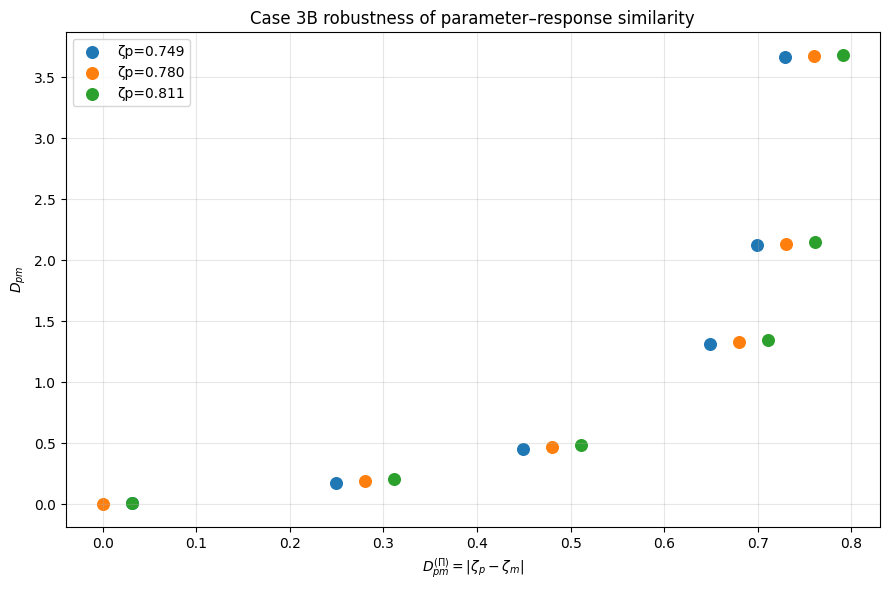

In [29]:
plt.figure(
    figsize=(9,6)
)

for zeta_p in ZETA_P_GRID:

    d = case3b_unique[
        np.isclose(
            case3b_unique[
                "zeta_p"
            ],
            zeta_p
        )
    ]

    label = (
        f"ζp={zeta_p:.3f}"
    )

    plt.scatter(
        d[
            "D_parameter"
        ],
        d[
            "D_response"
        ],
        s=70,
        label=label
    )


plt.xlabel(
    r"$D_{pm}^{(\Pi)}=|\zeta_p-\zeta_m|$"
)

plt.ylabel(
    r"$D_{pm}$"
)

plt.title(
    "Case 3B robustness of "
    "parameter–response similarity"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()

In [30]:
from scipy.stats import (
    pearsonr,
    spearmanr
)

pearson_3b = pearsonr(
    case3b_unique[
        "D_parameter"
    ],
    case3b_unique[
        "D_response"
    ]
)

spearman_3b = spearmanr(
    case3b_unique[
        "D_parameter"
    ],
    case3b_unique[
        "D_response"
    ]
)


print(
    "Case 3B Pearson r:",
    pearson_3b.statistic
)

print(
    "Case 3B Pearson p:",
    pearson_3b.pvalue
)

print(
    "Case 3B Spearman rho:",
    spearman_3b.statistic
)

print(
    "Case 3B Spearman p:",
    spearman_3b.pvalue
)

Case 3B Pearson r: 0.8166116518960201
Case 3B Pearson p: 3.5543945923897494e-05
Case 3B Spearman rho: 0.9855521155830752
Case 3B Spearman p: 9.124170334062525e-14


In [31]:
monotonicity_rows = []

for zeta_p in ZETA_P_GRID:

    d = (
        case3b_unique[
            np.isclose(
                case3b_unique[
                    "zeta_p"
                ],
                zeta_p
            )
        ]
        .sort_values(
            "D_parameter"
        )
    )

    Dp = (
        d[
            "D_parameter"
        ].to_numpy()
    )

    Dr = (
        d[
            "D_response"
        ].to_numpy()
    )

    rho = spearmanr(
        Dp,
        Dr
    )

    monotonic = bool(
        np.all(
            np.diff(Dr)
            >=
            -1e-12
        )
    )

    monotonicity_rows.append({

        "zeta_p":
            zeta_p,

        "spearman_rho":
            rho.statistic,

        "spearman_p":
            rho.pvalue,

        "strict_order_preserved":
            monotonic
    })


monotonicity_table = pd.DataFrame(
    monotonicity_rows
)

monotonicity_table

,zeta_p,spearman_rho,spearman_p,strict_order_preserved
0,0.749113,1.0,0.0,True
1,0.780009,1.0,0.0,True
2,0.810905,1.0,0.0,True


In [32]:
DPI_CLOSE = 0.05

close_region = (
    case3b_unique[
        case3b_unique[
            "D_parameter"
        ]
        <=
        DPI_CLOSE
    ]
)

far_region = (
    case3b_unique[
        case3b_unique[
            "D_parameter"
        ]
        >
        DPI_CLOSE
    ]
)


print(
    "Close-region comparisons:",
    len(close_region)
)

print(
    "Far-region comparisons:",
    len(far_region)
)

print(
    "\nClose-region maximum response distance:",
    close_region[
        "D_response"
    ].max()
)

print(
    "Close-region median response distance:",
    close_region[
        "D_response"
    ].median()
)

print(
    "\nFar-region minimum response distance:",
    far_region[
        "D_response"
    ].min()
)

Close-region comparisons: 3
Far-region comparisons: 15

Close-region maximum response distance: 0.015831641053799493
Close-region median response distance: 0.01492366245349327

Far-region minimum response distance: 0.17710257758740675


In [33]:
frequency_shift = pd.DataFrame({
    "Pi_C_m":
        PIC_M_GRID,

    "fn_m_Hz":
        FN_M0_HZ
        *
        np.sqrt(
            1.0
            +
            PIC_M_GRID
        )
})

frequency_shift[
    "frequency_shift_percent"
] = (
    100
    *
    (
        frequency_shift[
            "fn_m_Hz"
        ]
        /
        FN_M0_HZ
        -
        1
    )
)

frequency_shift

,Pi_C_m,fn_m_Hz,frequency_shift_percent
0,-0.10,310.405354,-5.131670
1,-0.05,318.911185,-2.532057
2,0.00,327.195972,0.000000
3,0.05,335.276102,2.469508
4,0.10,343.166031,4.880885


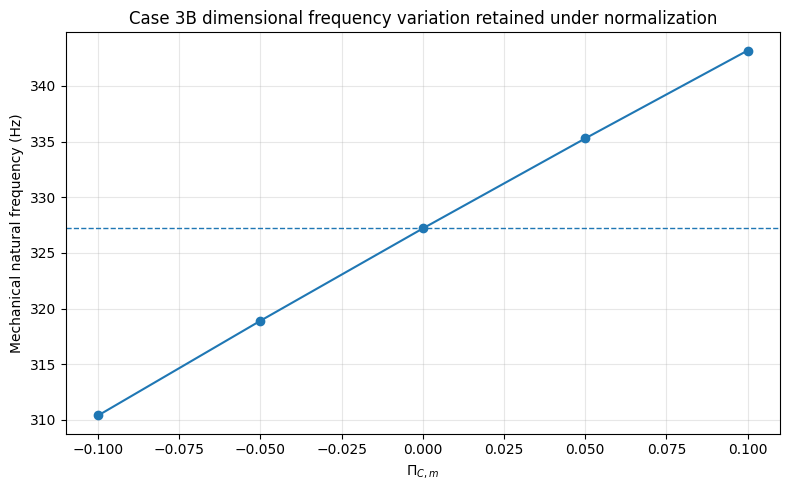

In [34]:
plt.figure(
    figsize=(8,5)
)

plt.plot(
    frequency_shift[
        "Pi_C_m"
    ],
    frequency_shift[
        "fn_m_Hz"
    ],
    marker="o"
)

plt.axhline(
    FN_M0_HZ,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    r"$\Pi_{C,m}$"
)

plt.ylabel(
    "Mechanical natural frequency (Hz)"
)

plt.title(
    "Case 3B dimensional frequency "
    "variation retained under normalization"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

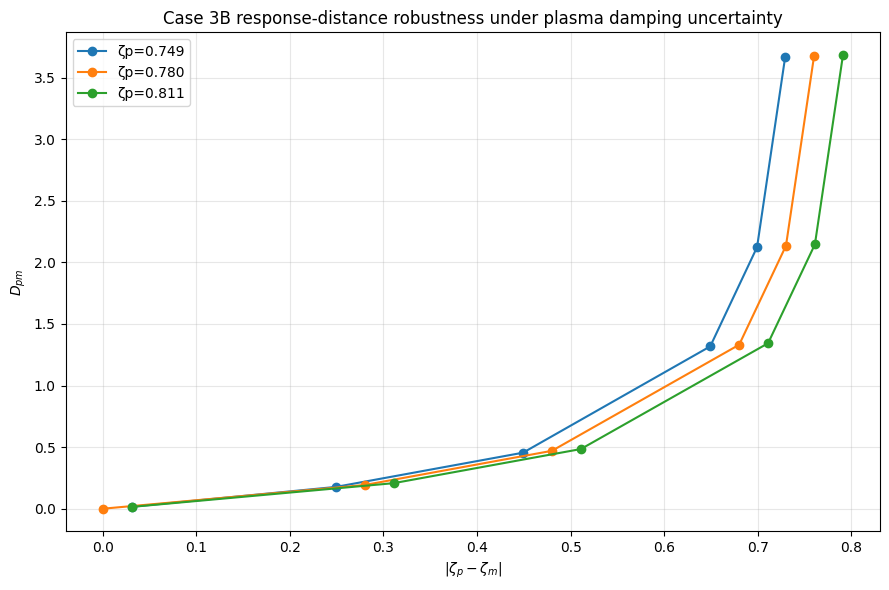

In [35]:
plt.figure(
    figsize=(9,6)
)

for zeta_p in ZETA_P_GRID:

    d = (
        case3b_unique[
            np.isclose(
                case3b_unique[
                    "zeta_p"
                ],
                zeta_p
            )
        ]
        .sort_values(
            "D_parameter"
        )
    )

    plt.plot(
        d[
            "D_parameter"
        ],
        d[
            "D_response"
        ],
        marker="o",
        label=f"ζp={zeta_p:.3f}"
    )


plt.xlabel(
    r"$|\zeta_p-\zeta_m|$"
)

plt.ylabel(
    r"$D_{pm}$"
)

plt.title(
    "Case 3B response-distance robustness "
    "under plasma damping uncertainty"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()

In [36]:
# Cell 36 — Estimate local sensitivity

LOCAL_LIMIT = 0.30

local_data = (
    case3b_unique[
        case3b_unique[
            "D_parameter"
        ]
        <= LOCAL_LIMIT
    ]
    .copy()
)

x_local = (
    local_data[
        "D_parameter"
    ]
    .to_numpy()
)

y_local = (
    local_data[
        "D_response"
    ]
    .to_numpy()
)

# Linear descriptive fit in the local region only
coef_local = np.polyfit(
    x_local,
    y_local,
    1
)

y_local_fit = np.polyval(
    coef_local,
    x_local
)

ss_res_local = np.sum(
    (
        y_local
        -
        y_local_fit
    )**2
)

ss_tot_local = np.sum(
    (
        y_local
        -
        y_local.mean()
    )**2
)

R2_local = (
    1.0
    -
    ss_res_local
    /
    ss_tot_local
)

print(
    "Local comparison count:",
    len(local_data)
)

print(
    "Local D_parameter limit:",
    LOCAL_LIMIT
)

print(
    "Local sensitivity slope dD_response/dD_parameter:",
    coef_local[0]
)

print(
    "Local intercept:",
    coef_local[1]
)

print(
    "Local descriptive R^2:",
    R2_local
)

Local comparison count: 5
Local D_parameter limit: 0.3
Local sensitivity slope dD_response/dD_parameter: 0.7128581587263852
Local intercept: -0.004111691061815639
Local descriptive R^2: 0.998631927878264


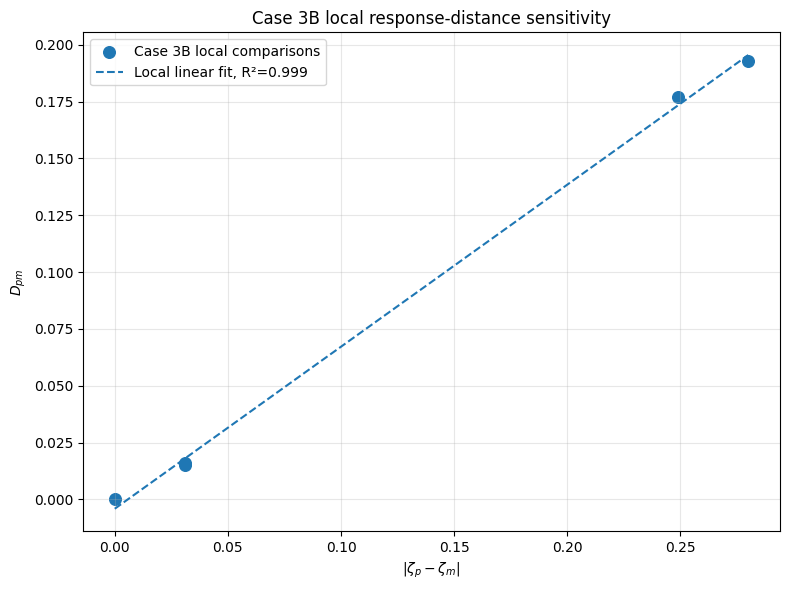

In [37]:
plt.figure(
    figsize=(8,6)
)

plt.scatter(
    x_local,
    y_local,
    s=70,
    label="Case 3B local comparisons"
)

x_fit_plot = np.linspace(
    x_local.min(),
    x_local.max(),
    200
)

y_fit_plot = np.polyval(
    coef_local,
    x_fit_plot
)

plt.plot(
    x_fit_plot,
    y_fit_plot,
    "--",
    label=(
        f"Local linear fit, "
        f"R²={R2_local:.3f}"
    )
)

plt.xlabel(
    r"$|\zeta_p-\zeta_m|$"
)

plt.ylabel(
    r"$D_{pm}$"
)

plt.title(
    "Case 3B local response-distance sensitivity"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()

In [38]:
case3b_summary_table = pd.DataFrame([
    {
        "metric":
            "total_factorial_comparisons",
        "value":
            len(case3b)
    },
    {
        "metric":
            "unique_damping_comparisons",
        "value":
            len(case3b_unique)
    },
    {
        "metric":
            "max_coupling_spread_after_normalization",
        "value":
            MAX_COUPLING_SPREAD
    },
    {
        "metric":
            "pearson_r",
        "value":
            pearson_3b.statistic
    },
    {
        "metric":
            "spearman_rho",
        "value":
            spearman_3b.statistic
    },
    {
        "metric":
            "close_region_max_D_response",
        "value":
            close_region[
                "D_response"
            ].max()
    },
    {
        "metric":
            "close_region_median_D_response",
        "value":
            close_region[
                "D_response"
            ].median()
    },
    {
        "metric":
            "far_region_min_D_response",
        "value":
            far_region[
                "D_response"
            ].min()
    },
    {
        "metric":
            "local_sensitivity_slope",
        "value":
            coef_local[0]
    },
    {
        "metric":
            "local_R2",
        "value":
            R2_local
    }
])

case3b_summary_table

,metric,value
0,total_factorial_comparisons,90.000000
1,unique_damping_comparisons,18.000000
2,max_coupling_spread_after_normalization,0.000000
3,pearson_r,0.816612
4,spearman_rho,0.985552
5,close_region_max_D_response,0.015832
6,close_region_median_D_response,0.014924
7,far_region_min_D_response,0.177103
8,local_sensitivity_slope,0.712858
9,local_R2,0.998632


In [39]:
CASE3B_CHECKS = {
    "all_plasma_levels_monotonic":
        bool(
            monotonicity_table[
                "strict_order_preserved"
            ].all()
        ),

    "coupling_invariance_after_normalization":
        bool(
            MAX_COUPLING_SPREAD
            < 1e-10
        ),

    "strong_rank_association":
        bool(
            spearman_3b.statistic
            >= 0.95
        ),

    "close_region_separated_from_far_region":
        bool(
            close_region[
                "D_response"
            ].max()
            <
            far_region[
                "D_response"
            ].min()
        )
}

CASE3B_CHECKS

{'all_plasma_levels_monotonic': True,
 'coupling_invariance_after_normalization': True,
 'strong_rank_association': True,
 'close_region_separated_from_far_region': True}

In [40]:
CASE3B_ROBUST = all(
    CASE3B_CHECKS.values()
)

print("CASE 3B ROBUSTNESS CHECK")
print("--------------------------------")

for key, value in CASE3B_CHECKS.items():
    print(
        f"{key}: {value}"
    )

print(
    "\nCASE 3B ROBUST:",
    CASE3B_ROBUST
)

CASE 3B ROBUSTNESS CHECK
--------------------------------
all_plasma_levels_monotonic: True
coupling_invariance_after_normalization: True
strong_rank_association: True
close_region_separated_from_far_region: True

CASE 3B ROBUST: True


In [41]:
print("CASE 3B SUMMARY")
print("--------------------------------")

print(
    "Factorial comparisons:",
    len(case3b)
)

print(
    "Unique damping comparisons:",
    len(case3b_unique)
)

print(
    "\nMaximum normalized-response spread "
    "from mechanical stiffness coupling:",
    MAX_COUPLING_SPREAD
)

print(
    "\nPearson r:",
    pearson_3b.statistic
)

print(
    "Spearman rho:",
    spearman_3b.statistic
)

print(
    "\nMonotonicity by plasma damping level:"
)

print(
    monotonicity_table
)

print(
    "\nClose-region max response distance:",
    close_region[
        "D_response"
    ].max()
)

print(
    "Far-region min response distance:",
    far_region[
        "D_response"
    ].min()
)

print(
    "\nLocal sensitivity slope:",
    coef_local[0]
)

print(
    "Local descriptive R^2:",
    R2_local
)

print(
    "\nCASE 3B ROBUST:",
    CASE3B_ROBUST
)

CASE 3B SUMMARY
--------------------------------
Factorial comparisons: 90
Unique damping comparisons: 18

Maximum normalized-response spread from mechanical stiffness coupling: 0.0

Pearson r: 0.8166116518960201
Spearman rho: 0.9855521155830752

Monotonicity by plasma damping level:
     zeta_p  spearman_rho  spearman_p  strict_order_preserved
0  0.749113           1.0         0.0                    True
1  0.780009           1.0         0.0                    True
2  0.810905           1.0         0.0                    True

Close-region max response distance: 0.015831641053799493
Far-region min response distance: 0.17710257758740675

Local sensitivity slope: 0.7128581587263852
Local descriptive R^2: 0.998631927878264

CASE 3B ROBUST: True


In [42]:
from pathlib import Path
import json

OUT3B = Path(
    "mea_case3b_outputs"
)

OUT3B.mkdir(
    exist_ok=True
)

case3b.to_csv(
    OUT3B
    /
    "case3b_full_factorial.csv",
    index=False
)

case3b_unique.to_csv(
    OUT3B
    /
    "case3b_unique_damping_comparisons.csv",
    index=False
)

coupling_spread.to_csv(
    OUT3B
    /
    "case3b_coupling_invariance.csv",
    index=False
)

monotonicity_table.to_csv(
    OUT3B
    /
    "case3b_monotonicity.csv",
    index=False
)

windowless_summary = {
    "total_factorial_comparisons":
        int(len(case3b)),

    "unique_damping_comparisons":
        int(len(case3b_unique)),

    "plasma_damping_grid":
        ZETA_P_GRID.tolist(),

    "mechanical_damping_grid":
        ZETA_M_GRID.tolist(),

    "mechanical_stiffness_coupling_grid":
        PIC_M_GRID.tolist(),

    "max_coupling_spread_after_normalization":
        float(
            MAX_COUPLING_SPREAD
        ),

    "association": {
        "pearson_r":
            float(
                pearson_3b.statistic
            ),

        "pearson_p":
            float(
                pearson_3b.pvalue
            ),

        "spearman_rho":
            float(
                spearman_3b.statistic
            ),

        "spearman_p":
            float(
                spearman_3b.pvalue
            )
    },

    "close_region": {
        "D_parameter_limit":
            float(DPI_CLOSE),

        "max_D_response":
            float(
                close_region[
                    "D_response"
                ].max()
            ),

        "median_D_response":
            float(
                close_region[
                    "D_response"
                ].median()
            ),

        "far_region_min_D_response":
            float(
                far_region[
                    "D_response"
                ].min()
            )
    },

    "local_sensitivity": {
        "D_parameter_limit":
            float(LOCAL_LIMIT),

        "slope":
            float(
                coef_local[0]
            ),

        "intercept":
            float(
                coef_local[1]
            ),

        "descriptive_R2":
            float(
                R2_local
            )
    },

    "checks":
        CASE3B_CHECKS,

    "robust":
        bool(
            CASE3B_ROBUST
        ),

    "interpretation":
        (
            "Cross-domain response similarity "
            "remains governed primarily by the "
            "shared damping coordinate across the "
            "Case-1 plasma damping uncertainty. "
            "Mechanical stiffness coupling changes "
            "the dimensional frequency scale but is "
            "removed from the normalized response "
            "when local natural frequency is used."
        )
}

with open(
    OUT3B
    /
    "case3b_summary.json",
    "w"
) as f:

    json.dump(
        windowless_summary,
        f,
        indent=2
    )

print(
    "Case 3B evidence exported to:",
    OUT3B.resolve()
)

Case 3B evidence exported to: /content/mea_case3b_outputs


In [ ]:
# ============================================================
# MEA FIGURES 4–5 — Case 3 preflight
# Inspect existing objects only
# ============================================================

keywords = (
    "case3",
    "plasma",
    "mechanical",
    "matched",
    "response",
    "distance",
    "parameter",
    "robust",
    "zeta",
    "omega",
    "phase",
    "sensitivity",
    "summary",
)

matches = []

# Snapshot globals to avoid dictionary-size RuntimeError
global_snapshot = list(globals().items())

for name, obj in global_snapshot:

    lname = name.lower()

    if (
        any(k in lname for k in keywords)
        and not name.startswith("_")
    ):

        typename = type(obj).__name__

        if hasattr(obj, "shape"):
            detail = f"shape={obj.shape}"

        elif isinstance(obj, (list, tuple, dict)):
            detail = f"len={len(obj)}"

        else:
            detail = ""

        matches.append(
            (name, typename, detail)
        )

for name, typename, detail in sorted(matches):
    print(
        f"{name:42s} "
        f"{typename:18s} "
        f"{detail}"
    )

CASE3B_CHECKS                              dict               len=4
CASE3B_ROBUST                              bool               
D_PHASE                                    float64            shape=()
D_response                                 function           
D_response_relative                        function           
H_PLASMA                                   ndarray            shape=(1001,)
OMEGA_3B                                   ndarray            shape=(1001,)
OMEGA_COMMON                               ndarray            shape=(1001,)
PHASE_M                                    ndarray            shape=(1001,)
PHASE_P                                    ndarray            shape=(1001,)
ZETA_COMPARE                               ndarray            shape=(6,)
ZETA_M_BASE                                float              
ZETA_M_GRID                                ndarray            shape=(6,)
ZETA_M_MATCH                               float              
ZETA_P              

In [ ]:
# ============================================================
# MEA FIGURES 4–5 — Inspect final Case 3 source objects
# ============================================================

objects_to_check = [
    "case3a_curves",
    "case3a_comparison",
    "case3b_unique",
    "case3b",
    "case3b_summary_table",
]

for name in objects_to_check:
    obj = globals()[name]

    print("\n" + "=" * 72)
    print(name)
    print("=" * 72)

    if hasattr(obj, "shape"):
        print("shape:", obj.shape)

    if hasattr(obj, "columns"):
        print("columns:", list(obj.columns))
        print(obj.head())

    elif isinstance(obj, dict):
        print(obj)

print("\n" + "=" * 72)
print("Key scalar / array values")
print("=" * 72)

for name in [
    "ZETA_P_MEAN",
    "ZETA_P_STD",
    "ZETA_P_LOW",
    "ZETA_P_HIGH",
    "ZETA_M_BASE",
    "ZETA_M_MATCH",
    "D_PHASE",
]:
    print(f"{name:20s} = {globals()[name]}")

print("\nZETA_P_GRID =", ZETA_P_GRID)
print("ZETA_M_GRID =", ZETA_M_GRID)
print("OMEGA_COMMON shape =", OMEGA_COMMON.shape)
print("PHASE_P shape =", PHASE_P.shape)
print("PHASE_M shape =", PHASE_M.shape)


case3a_curves
shape: (1001, 6)
columns: ['Omega', 'H_plasma', 'H_mechanical_baseline', 'H_mechanical_matched', 'phase_plasma_rad', 'phase_mechanical_matched_rad']
    Omega  H_plasma  H_mechanical_baseline  H_mechanical_matched  \
0  0.0000  1.000000               1.000000              1.000000   
1  0.0025  0.999999               1.000006              0.999999   
2  0.0050  0.999995               1.000025              0.999995   
3  0.0075  0.999988               1.000056              0.999988   
4  0.0100  0.999978               1.000100              0.999978   

   phase_plasma_rad  phase_mechanical_matched_rad  
0           -0.0000                       -0.0000  
1           -0.0039                       -0.0039  
2           -0.0078                       -0.0078  
3           -0.0117                       -0.0117  
4           -0.0156                       -0.0156  

case3a_comparison
shape: (6, 5)
columns: ['zeta_plasma', 'zeta_mechanical', 'D_parameter', 'D_response', 'D_respon

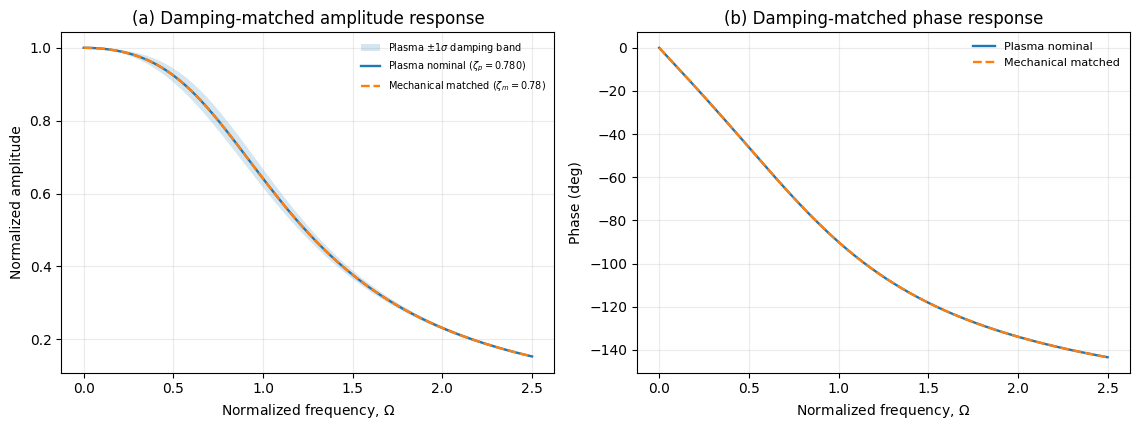

Saved:
  fig04_cross_domain_matched.pdf
  fig04_cross_domain_matched.png

Matched comparison:
D_parameter = 8.882382855124327e-06
D_response = 4.416793220759986e-06
D_response_relative = 7.029680941147546e-06
D_phase_rad = 4.5092604478625095e-06
D_phase_deg = 0.0002583615923877932
Plasma zeta nominal ±1 SD = 0.7800088823828552 ± 0.030895691295456208


In [ ]:
# ============================================================
# MEA PUBLICATION FIGURE 4
# Damping-matched plasma-mechanical comparison
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Source data
# ------------------------------------------------------------

df = case3a_curves.copy()

Omega = df["Omega"].to_numpy()

H_plasma = df["H_plasma"].to_numpy()
H_mech_matched = df["H_mechanical_matched"].to_numpy()

phase_plasma = np.degrees(
    df["phase_plasma_rad"].to_numpy()
)

phase_mech = np.degrees(
    df["phase_mechanical_matched_rad"].to_numpy()
)

# ------------------------------------------------------------
# Canonical modal response for plasma damping uncertainty
# ------------------------------------------------------------

def H_modal(Omega, zeta):
    return 1.0 / np.sqrt(
        (1.0 - Omega**2)**2
        +
        (2.0 * zeta * Omega)**2
    )

H_low_zeta = H_modal(
    Omega,
    ZETA_P_LOW
)

H_high_zeta = H_modal(
    Omega,
    ZETA_P_HIGH
)

# For a damping band, lower zeta gives the larger response
H_band_lower = np.minimum(
    H_low_zeta,
    H_high_zeta
)

H_band_upper = np.maximum(
    H_low_zeta,
    H_high_zeta
)

# ------------------------------------------------------------
# Figure layout
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.5, 4.4)
)

ax_amp, ax_phase = axes

# ------------------------------------------------------------
# Panel (a): normalized amplitude comparison
# ------------------------------------------------------------

ax_amp.fill_between(
    Omega,
    H_band_lower,
    H_band_upper,
    alpha=0.18,
    label=r"Plasma $\pm1\sigma$ damping band"
)

ax_amp.plot(
    Omega,
    H_plasma,
    linewidth=1.7,
    label=rf"Plasma nominal ($\zeta_p={ZETA_P_MEAN:.3f}$)"
)

ax_amp.plot(
    Omega,
    H_mech_matched,
    linestyle="--",
    linewidth=1.7,
    label=rf"Mechanical matched ($\zeta_m={ZETA_M_MATCH:.2f}$)"
)

ax_amp.set_title(
    "(a) Damping-matched amplitude response"
)

ax_amp.set_xlabel(
    r"Normalized frequency, $\Omega$"
)

ax_amp.set_ylabel(
    "Normalized amplitude"
)

ax_amp.grid(
    alpha=0.25
)

ax_amp.legend(
    fontsize=7,
    frameon=False
)

# ------------------------------------------------------------
# Panel (b): normalized phase comparison
# ------------------------------------------------------------

ax_phase.plot(
    Omega,
    phase_plasma,
    linewidth=1.7,
    label="Plasma nominal"
)

ax_phase.plot(
    Omega,
    phase_mech,
    linestyle="--",
    linewidth=1.7,
    label="Mechanical matched"
)

ax_phase.set_title(
    "(b) Damping-matched phase response"
)

ax_phase.set_xlabel(
    r"Normalized frequency, $\Omega$"
)

ax_phase.set_ylabel(
    "Phase (deg)"
)

ax_phase.grid(
    alpha=0.25
)

ax_phase.legend(
    fontsize=8,
    frameon=False
)

# ------------------------------------------------------------
# Layout and export
# ------------------------------------------------------------

plt.tight_layout()

fig.savefig(
    "fig04_cross_domain_matched.pdf",
    bbox_inches="tight"
)

fig.savefig(
    "fig04_cross_domain_matched.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Audit metrics
# ------------------------------------------------------------

matched_row = case3a_comparison.iloc[
    np.argmin(
        np.abs(
            case3a_comparison["zeta_mechanical"]
            -
            ZETA_M_MATCH
        )
    )
]

print("Saved:")
print("  fig04_cross_domain_matched.pdf")
print("  fig04_cross_domain_matched.png")

print("\nMatched comparison:")
print(
    "D_parameter =",
    matched_row["D_parameter"]
)
print(
    "D_response =",
    matched_row["D_response"]
)
print(
    "D_response_relative =",
    matched_row["D_response_relative"]
)

print(
    "D_phase_rad =",
    D_PHASE
)

print(
    "D_phase_deg =",
    np.degrees(D_PHASE)
)

print(
    "Plasma zeta nominal ±1 SD =",
    ZETA_P_MEAN,
    "±",
    ZETA_P_STD
)

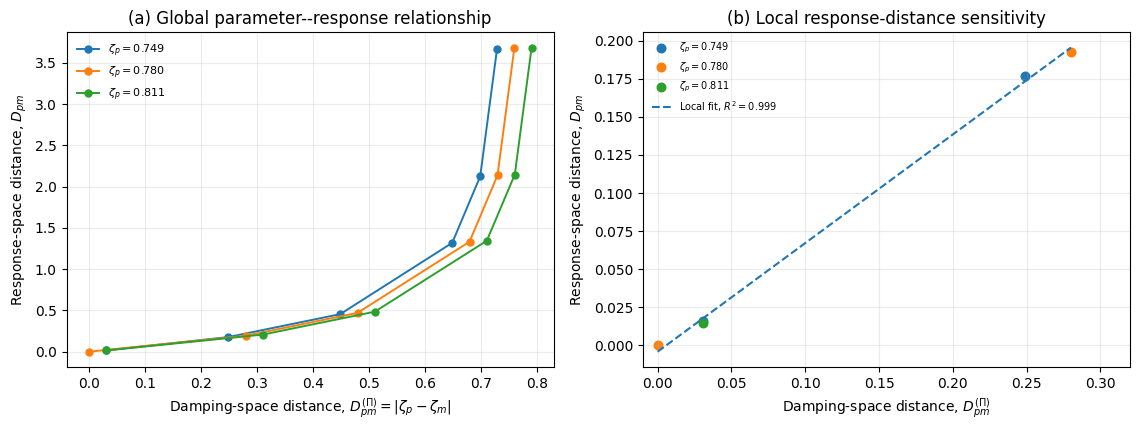

Saved:
  fig05_parameter_response.pdf
  fig05_parameter_response.png

Case 3B data:
Unique comparisons = 18
Plasma damping levels = [np.float64(0.7491131910873989), np.float64(0.7800088823828552), np.float64(0.8109045736783114)]

Global association:
Pearson r = 0.8166116518960201
Spearman rho = 0.9855521155830752

Local fit:
slope     = 0.712858
intercept = -0.004112
R^2       = 0.998632
N local   = 5

Local points:
  zeta_p  zeta_m  D_parameter  D_response
0.780009    0.78     0.000009    0.000004
0.749113    0.78     0.030887    0.015832
0.810905    0.78     0.030905    0.014924
0.749113    0.50     0.249113    0.177103
0.780009    0.50     0.280009    0.192823


In [ ]:
# ============================================================
# MEA PUBLICATION FIGURE 5
# Parameter-space versus response-space robustness
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Source data
# ------------------------------------------------------------

df = case3b_unique.copy()

# Sort for consistent plotting
df = df.sort_values(
    ["zeta_p", "D_parameter"]
).reset_index(drop=True)

zeta_levels = sorted(
    df["zeta_p"].unique()
)

# ------------------------------------------------------------
# Local region used for descriptive sensitivity fit
# ------------------------------------------------------------

LOCAL_LIMIT = 0.30

local_df = (
    df[
        df["D_parameter"] <= LOCAL_LIMIT
    ]
    .copy()
    .sort_values("D_parameter")
)

x_local = local_df["D_parameter"].to_numpy()
y_local = local_df["D_response"].to_numpy()

# Ordinary least-squares descriptive fit
slope, intercept = np.polyfit(
    x_local,
    y_local,
    1
)

y_fit = (
    slope * x_local
    +
    intercept
)

ss_res = np.sum(
    (y_local - y_fit)**2
)

ss_tot = np.sum(
    (y_local - y_local.mean())**2
)

r2_local = (
    1.0 - ss_res / ss_tot
    if ss_tot > 0
    else np.nan
)

# Smooth line only over observed local interval
x_fit = np.linspace(
    x_local.min(),
    x_local.max(),
    200
)

y_fit_line = (
    slope * x_fit
    +
    intercept
)

# ------------------------------------------------------------
# Figure layout
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.5, 4.4)
)

ax_global, ax_local = axes

# ------------------------------------------------------------
# Panel (a): global robustness relationship
# ------------------------------------------------------------

for zeta_p_level in zeta_levels:

    subset = (
        df[
            np.isclose(
                df["zeta_p"],
                zeta_p_level
            )
        ]
        .sort_values("D_parameter")
    )

    ax_global.plot(
        subset["D_parameter"],
        subset["D_response"],
        marker="o",
        linewidth=1.4,
        markersize=5,
        label=rf"$\zeta_p={zeta_p_level:.3f}$"
    )

ax_global.set_title(
    "(a) Global parameter--response relationship"
)

ax_global.set_xlabel(
    r"Damping-space distance, "
    r"$D_{pm}^{(\Pi)}=|\zeta_p-\zeta_m|$"
)

ax_global.set_ylabel(
    r"Response-space distance, $D_{pm}$"
)

ax_global.grid(
    alpha=0.25
)

ax_global.legend(
    fontsize=8,
    frameon=False
)

# ------------------------------------------------------------
# Panel (b): local sensitivity
# ------------------------------------------------------------

for zeta_p_level in zeta_levels:

    subset = (
        local_df[
            np.isclose(
                local_df["zeta_p"],
                zeta_p_level
            )
        ]
        .sort_values("D_parameter")
    )

    if len(subset) == 0:
        continue

    ax_local.scatter(
        subset["D_parameter"],
        subset["D_response"],
        s=38,
        label=rf"$\zeta_p={zeta_p_level:.3f}$"
    )

ax_local.plot(
    x_fit,
    y_fit_line,
    linestyle="--",
    linewidth=1.5,
    label=rf"Local fit, $R^2={r2_local:.3f}$"
)

ax_local.set_title(
    "(b) Local response-distance sensitivity"
)

ax_local.set_xlabel(
    r"Damping-space distance, "
    r"$D_{pm}^{(\Pi)}$"
)

ax_local.set_ylabel(
    r"Response-space distance, $D_{pm}$"
)

ax_local.set_xlim(
    left=-0.01,
    right=LOCAL_LIMIT + 0.02
)

ax_local.grid(
    alpha=0.25
)

ax_local.legend(
    fontsize=7,
    frameon=False
)

# ------------------------------------------------------------
# Final layout and export
# ------------------------------------------------------------

plt.tight_layout()

fig.savefig(
    "fig05_parameter_response.pdf",
    bbox_inches="tight"
)

fig.savefig(
    "fig05_parameter_response.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Audit output
# ------------------------------------------------------------

print("Saved:")
print("  fig05_parameter_response.pdf")
print("  fig05_parameter_response.png")

print("\nCase 3B data:")
print(
    "Unique comparisons =",
    len(df)
)
print(
    "Plasma damping levels =",
    zeta_levels
)

print("\nGlobal association:")
print(
    "Pearson r =",
    CASE3B_CHECKS.get(
        "pearson_r",
        case3b_summary_table.loc[
            case3b_summary_table["metric"] == "pearson_r",
            "value"
        ].iloc[0]
    )
)
print(
    "Spearman rho =",
    CASE3B_CHECKS.get(
        "spearman_rho",
        case3b_summary_table.loc[
            case3b_summary_table["metric"] == "spearman_rho",
            "value"
        ].iloc[0]
    )
)

print("\nLocal fit:")
print(
    f"slope     = {slope:.6f}"
)
print(
    f"intercept = {intercept:.6f}"
)
print(
    f"R^2       = {r2_local:.6f}"
)
print(
    f"N local   = {len(local_df)}"
)

print("\nLocal points:")
print(
    local_df[
        [
            "zeta_p",
            "zeta_m",
            "D_parameter",
            "D_response"
        ]
    ].to_string(index=False)
)

In [ ]:
# ============================================================
# CASE 3C — REVIEWER-RESPONSE ACTUAL FRF COMPARISON
#
# Objective:
# Compare the actual identified plasma input-output FRFs,
# retaining zeros, residues, DC gain, and phase, against:
#
#   1. exact nominal surrogate linearization FRFs;
#   2. canonical denominator-only modal approximation;
#   3. independently derived structural displacement FRF.
#
# Primary outputs:
#   G_theta_u(s)
#   G_r_u(s)
#
# Primary normalization:
#   signed/DC-static-gain normalization
#
# No post hoc output selection.
# No peak normalization.
# No fitted residue normalization.
# ============================================================

In [43]:
# ============================================================
# CASE 3C — PREFLIGHT
# Inspect Case 3 runtime and required Case 1 evidence objects
# ============================================================

required_case3 = [
    "case3a_curves",
    "case3a_comparison",
    "case3b_unique",
    "OMEGA_COMMON",
    "ZETA_M_MATCH",
]

required_case1 = [
    "case1b_results",
    "case1f_models",
    "A0",
    "B0",
    "tf_theta_0",
    "tf_r_0",
]

print("Case 3 objects:")
for name in required_case3:
    print(f"{name:24s}: {name in globals()}")

print("\nCase 1 reviewer-response objects:")
for name in required_case1:
    print(f"{name:24s}: {name in globals()}")

print("\nOther likely Case 3 mechanical objects:")

keywords = (
    "m1",
    "k1",
    "c1",
    "omega1",
    "omega_n",
    "zeta",
    "mechanical",
    "structural",
    "frf",
    "case3",
)

snapshot = list(globals().items())

for name, obj in sorted(snapshot):
    lname = name.lower()

    if (
        any(k in lname for k in keywords)
        and not name.startswith("_")
    ):
        if hasattr(obj, "shape"):
            print(
                f"{name:36s} "
                f"{type(obj).__name__:18s} "
                f"shape={obj.shape}"
            )
        elif isinstance(obj, (list, tuple, dict)):
            print(
                f"{name:36s} "
                f"{type(obj).__name__:18s} "
                f"len={len(obj)}"
            )

Case 3 objects:
case3a_curves           : True
case3a_comparison       : True
case3b_unique           : True
OMEGA_COMMON            : True
ZETA_M_MATCH            : True

Case 1 reviewer-response objects:
case1b_results          : False
case1f_models           : False
A0                      : False
B0                      : False
tf_theta_0              : False
tf_r_0                  : False

Other likely Case 3 mechanical objects:
CASE3B_CHECKS                        dict               len=4
ZETA_COMPARE                         ndarray            shape=(6,)
ZETA_M_GRID                          ndarray            shape=(6,)
ZETA_P_GRID                          ndarray            shape=(3,)
case3a_comparison                    DataFrame          shape=(6, 5)
case3a_curves                        DataFrame          shape=(1001, 6)
case3a_summary                       dict               len=8
case3b                               DataFrame          shape=(90, 7)
case3b_rows              

In [44]:
# ============================================================
# CASE 1 → CASE 3C EVIDENCE EXPORT
#
# Compact immutable package containing only the identified
# state-space evidence needed for the actual-FRF experiment.
# ============================================================

import numpy as np
import json

export = {}

# ------------------------------------------------------------
# Exact nominal linearization
# ------------------------------------------------------------

export["A0"] = np.asarray(A0, dtype=float)
export["B0"] = np.asarray(B0, dtype=float)

# ------------------------------------------------------------
# Original six Case 1B local identifications
# ------------------------------------------------------------

amps_1b = np.array(
    [float(r["amp"]) for r in case1b_results],
    dtype=float
)

A_1b = np.stack(
    [np.asarray(r["A"], dtype=float) for r in case1b_results]
)

B_1b = np.stack(
    [np.asarray(r["B"], dtype=float).reshape(2, 1)
     for r in case1b_results]
)

export["case1b_amps"] = amps_1b
export["case1b_A"] = A_1b
export["case1b_B"] = B_1b

# ------------------------------------------------------------
# Six Case 1F LOPO common models
# ------------------------------------------------------------

amps_1f = np.array(
    sorted(float(k) for k in case1f_models.keys()),
    dtype=float
)

A_1f = np.stack([
    np.asarray(
        case1f_models[float(a)]["A"],
        dtype=float
    )
    for a in amps_1f
])

B_1f = np.stack([
    np.asarray(
        case1f_models[float(a)]["B"],
        dtype=float
    ).reshape(2, 1)
    for a in amps_1f
])

export["case1f_held_out_amps"] = amps_1f
export["case1f_A"] = A_1f
export["case1f_B"] = B_1f

# ------------------------------------------------------------
# Surrogate constants for exact reconstruction/audit
# ------------------------------------------------------------

export["tau_T_s"] = np.array(SURROGATE["tau_T_s"])
export["tau_n_s"] = np.array(SURROGATE["tau_n_s"])
export["a"] = np.array(SURROGATE["a"])
export["b"] = np.array(SURROGATE["b"])
export["c"] = np.array(SURROGATE["c"])
export["d"] = np.array(SURROGATE["d"])

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

np.savez(
    "MEA_case1_reviewer_evidence_for_case3c.npz",
    **export
)

print("Saved:")
print("  MEA_case1_reviewer_evidence_for_case3c.npz")

print("\nContents:")
for key, value in export.items():
    print(
        f"{key:28s}",
        np.asarray(value).shape
    )

NameError: name 'A0' is not defined

In [ ]:
print("Case 1 export preflight:")
for name in [
    "SURROGATE",
    "case1b_results",
    "case1f_models",
]:
    print(
        f"{name:20s}:",
        name in globals()
    )

Case 1 export preflight:
SURROGATE           : False
case1b_results      : False
case1f_models       : False


In [45]:
# ============================================================
# CASE 3C — RUNTIME + IMPORT PREFLIGHT
# ============================================================

import os
import numpy as np

print("Case 3 runtime objects:")
for name in [
    "case3a_curves",
    "case3a_comparison",
    "case3b_unique",
    "OMEGA_COMMON",
    "ZETA_M_MATCH",
]:
    print(f"{name:24s}: {name in globals()}")

print("\nCase 1 evidence file:")
filename = "MEA_case1_reviewer_evidence_for_case3c.npz"
print("file exists:", os.path.exists(filename))

if os.path.exists(filename):
    evidence = np.load(filename)

    print("\nEvidence contents:")
    for key in evidence.files:
        print(
            f"{key:28s}",
            evidence[key].shape
        )

Case 3 runtime objects:
case3a_curves           : True
case3a_comparison       : True
case3b_unique           : True
OMEGA_COMMON            : True
ZETA_M_MATCH            : True

Case 1 evidence file:
file exists: True

Evidence contents:
A0                           (2, 2)
B0                           (2, 1)
case1b_amps                  (6,)
case1b_A                     (6, 2, 2)
case1b_B                     (6, 2, 1)
case1f_held_out_amps         (6,)
case1f_A                     (6, 2, 2)
case1f_B                     (6, 2, 1)
tau_T_s                      ()
tau_n_s                      ()
a                            ()
b                            ()
c                            ()
d                            ()


In [46]:
# ============================================================
# CASE 3C — LOAD CASE 1 EVIDENCE
# ============================================================

case1_evidence = np.load(
    "MEA_case1_reviewer_evidence_for_case3c.npz"
)

A0 = case1_evidence["A0"]
B0 = case1_evidence["B0"]

CASE1B_AMPS = case1_evidence["case1b_amps"]
CASE1B_A = case1_evidence["case1b_A"]
CASE1B_B = case1_evidence["case1b_B"]

CASE1F_AMPS = case1_evidence["case1f_held_out_amps"]
CASE1F_A = case1_evidence["case1f_A"]
CASE1F_B = case1_evidence["case1f_B"]

print("Case 1 evidence loaded successfully.")

print("\nA0:")
print(A0)

print("\nB0:")
print(B0)

print("\nCase 1B:")
print("amps:", CASE1B_AMPS)
print("A shape:", CASE1B_A.shape)
print("B shape:", CASE1B_B.shape)

print("\nCase 1F:")
print("amps:", CASE1F_AMPS)
print("A shape:", CASE1F_A.shape)
print("B shape:", CASE1F_B.shape)

Case 1 evidence loaded successfully.

A0:
[[-2857142.85714286 -2142857.14285714]
 [ 1500000.         -1666666.66666667]]

B0:
[[-2571428.57142857]
 [ 2500000.        ]]

Case 1B:
amps: [-0.1   -0.05  -0.025  0.025  0.05   0.1  ]
A shape: (6, 2, 2)
B shape: (6, 2, 1)

Case 1F:
amps: [-0.1   -0.05  -0.025  0.025  0.05   0.1  ]
A shape: (6, 2, 2)
B shape: (6, 2, 1)


In [47]:
# ============================================================
# CASE 3C — PRE-REGISTERED ACTUAL-FRF COMPARISON PROTOCOL
#
# Purpose:
# Test whether cross-domain correspondence survives when the
# full identified plasma input-output dynamics are retained.
#
# Primary plasma outputs:
#   theta
#   r
#
# Primary structural output:
#   displacement
#
# Primary normalization:
#   signed/DC-static-gain normalization
#
# Frequency normalization:
#   Omega = omega / omega_n
#
# Comparison interval:
#   0.05 <= Omega <= 2.50
#
# Primary metrics:
#   - RMS magnitude distance
#   - relative complex FRF error
#   - RMS phase distance
#   - maximum magnitude error
#
# No:
#   - output cherry-picking
#   - peak normalization
#   - fitted residue normalization
#   - fitted phase correction
#   - post hoc bandwidth selection
# ============================================================

CASE3C_PROTOCOL = {
    "Omega_min": 0.05,
    "Omega_max": 2.50,
    "N_Omega": 1001,
    "normalization": "DC/static gain",
    "plasma_outputs": ["theta", "r"],
    "structural_output": "displacement",
    "compare_amplitude": True,
    "compare_phase": True,
    "exclude_Omega_zero_from_metric": True,
}

print("CASE 3C protocol frozen:")
for k, v in CASE3C_PROTOCOL.items():
    print(f"{k:34s}: {v}")

CASE 3C protocol frozen:
Omega_min                         : 0.05
Omega_max                         : 2.5
N_Omega                           : 1001
normalization                     : DC/static gain
plasma_outputs                    : ['theta', 'r']
structural_output                 : displacement
compare_amplitude                 : True
compare_phase                     : True
exclude_Omega_zero_from_metric    : True


In [48]:
# ============================================================
# CASE 3C — ACTUAL PLASMA FRFs
#
# Construct:
#   1. exact nominal surrogate FRFs
#   2. six Case 1B identified local FRFs
#   3. six Case 1F common-model FRFs
#   4. canonical denominator-only modal approximation
#   5. structural displacement FRF
#
# No plotting yet.
# ============================================================

import numpy as np
import pandas as pd

from scipy.signal import ss2tf


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

C_THETA = np.array([[1.0, 0.0]])
C_R     = np.array([[0.0, 1.0]])
D_ZERO  = np.array([[0.0]])


def modal_from_A_3c(A):

    eigvals = np.linalg.eigvals(
        np.asarray(A, dtype=float)
    )

    eigp = eigvals[
        np.argmax(
            np.imag(eigvals)
        )
    ]

    sigma = -np.real(eigp)
    wd = abs(np.imag(eigp))

    wn = np.sqrt(
        sigma**2 + wd**2
    )

    zeta = sigma / wn

    return {
        "eigvals": eigvals,
        "sigma": float(sigma),
        "wd": float(wd),
        "wn": float(wn),
        "fn_Hz": float(wn/(2*np.pi)),
        "zeta": float(zeta)
    }


def tf_coefficients(A, B, C):

    num, den = ss2tf(
        np.asarray(A, dtype=float),
        np.asarray(B, dtype=float),
        np.asarray(C, dtype=float),
        D_ZERO
    )

    num = np.asarray(num[0], dtype=float)
    den = np.asarray(den, dtype=float)

    tol = (
        1e-12
        *
        max(
            1.0,
            np.max(np.abs(num))
        )
    )

    nz = np.where(
        np.abs(num) > tol
    )[0]

    if len(nz):
        num = num[nz[0]:]
    else:
        num = np.array([0.0])

    zeros = (
        np.roots(num)
        if len(num) > 1
        else np.array([])
    )

    poles = np.roots(den)

    dc_gain = (
        num[-1] / den[-1]
    )

    rel_degree = (
        len(den) - len(num)
    )

    return {
        "num": num,
        "den": den,
        "zeros": zeros,
        "poles": poles,
        "dc_gain": float(dc_gain),
        "relative_degree": int(rel_degree)
    }


def eval_tf(num, den, s):

    return (
        np.polyval(num, s)
        /
        np.polyval(den, s)
    )


def normalized_complex_frf(A, B, C, Omega):

    modal = modal_from_A_3c(A)
    tf = tf_coefficients(A, B, C)

    s = 1j * Omega * modal["wn"]

    H = eval_tf(
        tf["num"],
        tf["den"],
        s
    )

    H0 = tf["dc_gain"]

    Hn = H / H0

    return {
        "H": H,
        "Hn": Hn,
        "modal": modal,
        "tf": tf
    }


# ------------------------------------------------------------
# Common normalized frequency grid
# ------------------------------------------------------------

OMEGA_3C = np.linspace(
    CASE3C_PROTOCOL["Omega_min"],
    CASE3C_PROTOCOL["Omega_max"],
    CASE3C_PROTOCOL["N_Omega"]
)


# ------------------------------------------------------------
# Exact nominal surrogate FRFs
# ------------------------------------------------------------

exact_theta = normalized_complex_frf(
    A0,
    B0,
    C_THETA,
    OMEGA_3C
)

exact_r = normalized_complex_frf(
    A0,
    B0,
    C_R,
    OMEGA_3C
)


# ------------------------------------------------------------
# Case 1B local FRFs
# ------------------------------------------------------------

case1b_frf = {}

for i, amp in enumerate(CASE1B_AMPS):

    A = CASE1B_A[i]
    B = CASE1B_B[i]

    case1b_frf[float(amp)] = {
        "theta":
            normalized_complex_frf(
                A, B, C_THETA, OMEGA_3C
            ),
        "r":
            normalized_complex_frf(
                A, B, C_R, OMEGA_3C
            )
    }


# ------------------------------------------------------------
# Case 1F LOPO common-model FRFs
# ------------------------------------------------------------

case1f_frf = {}

for i, amp in enumerate(CASE1F_AMPS):

    A = CASE1F_A[i]
    B = CASE1F_B[i]

    case1f_frf[float(amp)] = {
        "theta":
            normalized_complex_frf(
                A, B, C_THETA, OMEGA_3C
            ),
        "r":
            normalized_complex_frf(
                A, B, C_R, OMEGA_3C
            )
    }


# ------------------------------------------------------------
# Canonical denominator-only response
#
# Use exact nominal pole-derived damping for reference.
# Complex form rather than magnitude-only H(Omega,zeta).
# ------------------------------------------------------------

zeta_exact = exact_theta[
    "modal"
]["zeta"]

H_CANONICAL = (
    1.0
    /
    (
        1.0
        -
        OMEGA_3C**2
        +
        1j
        *
        2.0
        *
        zeta_exact
        *
        OMEGA_3C
    )
)


# ------------------------------------------------------------
# Mechanical displacement FRF
#
# After static-gain and natural-frequency normalization:
#
#     H_m =
#       1 / (1 - Omega^2 + i 2 zeta_m Omega)
#
# Use the existing Case 3 matched mechanical damping.
# ------------------------------------------------------------

H_MECH = (
    1.0
    /
    (
        1.0
        -
        OMEGA_3C**2
        +
        1j
        *
        2.0
        *
        ZETA_M_MATCH
        *
        OMEGA_3C
    )
)


print("Case 3C FRFs constructed.")

print("\nExact plasma modal reference:")
print(
    "fn =",
    exact_theta["modal"]["fn_Hz"],
    "Hz"
)
print(
    "zeta =",
    exact_theta["modal"]["zeta"]
)

print("\nExact theta:")
print(
    "zero =",
    exact_theta["tf"]["zeros"]
)
print(
    "DC gain =",
    exact_theta["tf"]["dc_gain"]
)
print(
    "relative degree =",
    exact_theta["tf"]["relative_degree"]
)

print("\nExact r:")
print(
    "zero =",
    exact_r["tf"]["zeros"]
)
print(
    "DC gain =",
    exact_r["tf"]["dc_gain"]
)
print(
    "relative degree =",
    exact_r["tf"]["relative_degree"]
)

Case 3C FRFs constructed.

Exact plasma modal reference:
fn = 449487.78070275753 Hz
zeta = 0.8008967965656446

Exact theta:
zero = [-3750000.]
DC gain = -1.2089552238805972
relative degree = 1

Exact r:
zero = [-1314285.71428571]
DC gain = 0.41194029850746283
relative degree = 1


In [49]:
# ============================================================
# CASE 3C — PRE-SPECIFIED RESPONSE-DISTANCE METRICS
# ============================================================

def frf_metrics(H_ref, H_cmp):

    H_ref = np.asarray(H_ref, dtype=complex)
    H_cmp = np.asarray(H_cmp, dtype=complex)

    mag_ref = np.abs(H_ref)
    mag_cmp = np.abs(H_cmp)

    phase_ref = np.unwrap(
        np.angle(H_ref)
    )

    phase_cmp = np.unwrap(
        np.angle(H_cmp)
    )

    mag_rms = np.sqrt(
        np.mean(
            (mag_ref - mag_cmp)**2
        )
    )

    complex_rel = (
        np.linalg.norm(
            H_ref - H_cmp
        )
        /
        np.linalg.norm(
            H_ref
        )
    )

    phase_rms_rad = np.sqrt(
        np.mean(
            (phase_ref - phase_cmp)**2
        )
    )

    max_mag_error = np.max(
        np.abs(
            mag_ref - mag_cmp
        )
    )

    return {
        "mag_rms":
            float(mag_rms),

        "complex_relative":
            float(complex_rel),

        "phase_rms_rad":
            float(phase_rms_rad),

        "phase_rms_deg":
            float(
                np.degrees(
                    phase_rms_rad
                )
            ),

        "max_mag_error":
            float(max_mag_error)
    }


metric_rows = []


# ------------------------------------------------------------
# Exact actual FRF vs canonical modal approximation
# ------------------------------------------------------------

for output, exact in [
    ("theta", exact_theta),
    ("r", exact_r),
]:

    m = frf_metrics(
        exact["Hn"],
        H_CANONICAL
    )

    metric_rows.append({
        "model":
            "exact surrogate",
        "output":
            output,
        "comparison":
            "actual vs canonical",
        **m
    })


# ------------------------------------------------------------
# Exact actual FRF vs mechanical displacement FRF
# ------------------------------------------------------------

for output, exact in [
    ("theta", exact_theta),
    ("r", exact_r),
]:

    m = frf_metrics(
        exact["Hn"],
        H_MECH
    )

    metric_rows.append({
        "model":
            "exact surrogate",
        "output":
            output,
        "comparison":
            "actual vs mechanical",
        **m
    })


# ------------------------------------------------------------
# Case 1B identified actual FRFs vs mechanical
# ------------------------------------------------------------

for amp, block in case1b_frf.items():

    for output in [
        "theta",
        "r"
    ]:

        m = frf_metrics(
            block[output]["Hn"],
            H_MECH
        )

        metric_rows.append({
            "model":
                "Case1B local",
            "identifier":
                amp,
            "output":
                output,
            "comparison":
                "actual vs mechanical",
            **m
        })


# ------------------------------------------------------------
# Case 1F LOPO actual FRFs vs mechanical
# ------------------------------------------------------------

for amp, block in case1f_frf.items():

    for output in [
        "theta",
        "r"
    ]:

        m = frf_metrics(
            block[output]["Hn"],
            H_MECH
        )

        metric_rows.append({
            "model":
                "Case1F LOPO",
            "identifier":
                amp,
            "output":
                output,
            "comparison":
                "actual vs mechanical",
            **m
        })


case3c_metrics = pd.DataFrame(
    metric_rows
)


print("=" * 100)
print("CASE 3C — EXACT REFERENCE COMPARISONS")
print("=" * 100)

print(
    case3c_metrics[
        case3c_metrics[
            "model"
        ]
        ==
        "exact surrogate"
    ].to_string(
        index=False
    )
)


print("\n" + "=" * 100)
print("CASE 3C — CASE 1B IDENTIFIED FRFs")
print("=" * 100)

print(
    case3c_metrics[
        case3c_metrics[
            "model"
        ]
        ==
        "Case1B local"
    ][
        [
            "identifier",
            "output",
            "mag_rms",
            "complex_relative",
            "phase_rms_deg",
            "max_mag_error"
        ]
    ].to_string(
        index=False
    )
)


print("\n" + "=" * 100)
print("CASE 3C — CASE 1F LOPO FRFs")
print("=" * 100)

print(
    case3c_metrics[
        case3c_metrics[
            "model"
        ]
        ==
        "Case1F LOPO"
    ][
        [
            "identifier",
            "output",
            "mag_rms",
            "complex_relative",
            "phase_rms_deg",
            "max_mag_error"
        ]
    ].to_string(
        index=False
    )
)

CASE 3C — EXACT REFERENCE COMPARISONS
          model output           comparison  mag_rms  complex_relative  phase_rms_rad  phase_rms_deg  max_mag_error  identifier
exact surrogate  theta  actual vs canonical 0.151770          0.519422       0.756357      43.336040       0.188646         NaN
exact surrogate      r  actual vs canonical 0.717725          0.866315       1.136887      65.138799       0.897374         NaN
exact surrogate  theta actual vs mechanical 0.144384          0.518852       0.762975      43.715266       0.183115         NaN
exact surrogate      r actual vs mechanical 0.709330          0.865880       1.142236      65.445327       0.885892         NaN

CASE 3C — CASE 1B IDENTIFIED FRFs
 identifier output  mag_rms  complex_relative  phase_rms_deg  max_mag_error
     -0.100  theta 0.145310          0.520181      43.794498       0.184217
     -0.100      r 0.694597          0.862459      65.178887       0.867375
     -0.050  theta 0.149126          0.525622      44.11886

In [50]:
# ============================================================
# CASE 3D — BEST-ACHIEVABLE STRUCTURAL CORRESPONDENCE
#
# Objective:
# Determine whether the full plasma input-output FRFs can be
# approximated by ANY canonical structural displacement FRF
# merely by varying mechanical damping.
#
# Fixed from Case 3C:
#   Omega range = 0.05 ... 2.50
#   DC/static-gain normalization
#   full complex FRF comparison
#   theta and r both evaluated
#
# Search:
#   0.001 <= zeta_m <= 2.0
#
# Primary optimization metric:
#   relative complex FRF error
#
# No:
#   - frequency-band adjustment
#   - output selection
#   - phase correction
#   - residue fitting
#   - peak normalization
# ============================================================

import numpy as np
import pandas as pd

from scipy.optimize import minimize_scalar


CASE3D_PROTOCOL = {
    "zeta_min": 0.001,
    "zeta_max": 2.0,
    "objective": "relative complex FRF error",
    "Omega_min": CASE3C_PROTOCOL["Omega_min"],
    "Omega_max": CASE3C_PROTOCOL["Omega_max"],
    "outputs": ["theta", "r"],
}

print("CASE 3D protocol frozen:")
for key, value in CASE3D_PROTOCOL.items():
    print(f"{key:28s}: {value}")

CASE 3D protocol frozen:
zeta_min                    : 0.001
zeta_max                    : 2.0
objective                   : relative complex FRF error
Omega_min                   : 0.05
Omega_max                   : 2.5
outputs                     : ['theta', 'r']


In [51]:
# ============================================================
# CASE 3D — OPTIMIZATION FUNCTIONS
# ============================================================

def mechanical_normalized_frf(
    Omega,
    zeta
):
    """
    Static-gain-normalized structural displacement FRF:

        Hm = 1 / (1 - Omega^2 + i 2 zeta Omega)
    """

    return (
        1.0
        /
        (
            1.0
            -
            Omega**2
            +
            1j
            *
            2.0
            *
            zeta
            *
            Omega
        )
    )


def complex_relative_distance(
    H_ref,
    H_cmp
):
    return float(
        np.linalg.norm(
            H_ref - H_cmp
        )
        /
        np.linalg.norm(
            H_ref
        )
    )


def optimize_mechanical_damping(
    H_plasma
):
    """
    Find zeta_m that minimizes relative complex FRF distance.
    """

    def objective(zeta):

        Hm = mechanical_normalized_frf(
            OMEGA_3C,
            zeta
        )

        return complex_relative_distance(
            H_plasma,
            Hm
        )

    result = minimize_scalar(
        objective,
        bounds=(
            CASE3D_PROTOCOL["zeta_min"],
            CASE3D_PROTOCOL["zeta_max"]
        ),
        method="bounded",
        options={
            "xatol": 1e-10,
            "maxiter": 1000
        }
    )

    zeta_star = float(
        result.x
    )

    Hm_star = mechanical_normalized_frf(
        OMEGA_3C,
        zeta_star
    )

    metrics = frf_metrics(
        H_plasma,
        Hm_star
    )

    return {
        "zeta_star":
            zeta_star,

        "optimizer_success":
            bool(
                result.success
            ),

        "objective_min":
            float(
                result.fun
            ),

        **metrics
    }

In [52]:
# ============================================================
# CASE 3D — EXACT + LOPO BEST-FIT RESULTS
# ============================================================

case3d_rows = []


# ------------------------------------------------------------
# Exact surrogate
# ------------------------------------------------------------

for output, exact_block in [
    ("theta", exact_theta),
    ("r", exact_r),
]:

    result = optimize_mechanical_damping(
        exact_block["Hn"]
    )

    case3d_rows.append({
        "model":
            "exact surrogate",

        "identifier":
            np.nan,

        "output":
            output,

        **result
    })


# ------------------------------------------------------------
# Six Case 1F LOPO plasma FRFs
# ------------------------------------------------------------

for amp, block in case1f_frf.items():

    for output in [
        "theta",
        "r"
    ]:

        result = optimize_mechanical_damping(
            block[output]["Hn"]
        )

        case3d_rows.append({
            "model":
                "Case1F LOPO",

            "identifier":
                float(amp),

            "output":
                output,

            **result
        })


case3d_results = pd.DataFrame(
    case3d_rows
)


print("=" * 100)
print("CASE 3D — BEST-ACHIEVABLE STRUCTURAL CORRESPONDENCE")
print("=" * 100)

print(
    case3d_results[
        [
            "model",
            "identifier",
            "output",
            "zeta_star",
            "complex_relative",
            "mag_rms",
            "phase_rms_deg",
            "max_mag_error",
            "optimizer_success"
        ]
    ].to_string(
        index=False
    )
)

CASE 3D — BEST-ACHIEVABLE STRUCTURAL CORRESPONDENCE
          model  identifier output  zeta_star  complex_relative  mag_rms  phase_rms_deg  max_mag_error  optimizer_success
exact surrogate         NaN  theta   0.768927          0.518770 0.140509      43.923094       0.180555               True
exact surrogate         NaN      r   0.718399          0.865279 0.682916      66.434701       0.851676               True
    Case1F LOPO      -0.100  theta   0.776322          0.570412 0.174638      47.254873       0.222714               True
    Case1F LOPO      -0.100      r   0.722467          0.881647 0.753658      67.910617       0.937337               True
    Case1F LOPO      -0.050  theta   0.769435          0.555195 0.164437      46.243745       0.210077               True
    Case1F LOPO      -0.050      r   0.718668          0.873269 0.716842      67.127388       0.893207               True
    Case1F LOPO      -0.025  theta   0.775908          0.556157 0.164471      46.356541       

In [53]:
# ============================================================
# CASE 3D — HOW MUCH DOES OPTIMIZING DAMPING ACTUALLY HELP?
# ============================================================

comparison_rows = []


def get_case3c_metric(
    model,
    output,
    identifier=None
):

    mask = (
        case3c_metrics["model"]
        ==
        model
    ) & (
        case3c_metrics["output"]
        ==
        output
    ) & (
        case3c_metrics["comparison"]
        ==
        "actual vs mechanical"
    )

    if identifier is not None:

        mask = (
            mask
            &
            np.isclose(
                case3c_metrics[
                    "identifier"
                ],
                identifier
            )
        )

    row = (
        case3c_metrics[
            mask
        ]
        .iloc[0]
    )

    return row


for _, row in case3d_results.iterrows():

    model = row["model"]
    output = row["output"]

    identifier = (
        None
        if pd.isna(
            row["identifier"]
        )
        else float(
            row["identifier"]
        )
    )

    old = get_case3c_metric(
        model,
        output,
        identifier
    )

    old_complex = float(
        old[
            "complex_relative"
        ]
    )

    new_complex = float(
        row[
            "complex_relative"
        ]
    )

    improvement = (
        1.0
        -
        new_complex
        /
        old_complex
    )

    comparison_rows.append({

        "model":
            model,

        "identifier":
            row[
                "identifier"
            ],

        "output":
            output,

        "zeta_original":
            ZETA_M_MATCH,

        "zeta_star":
            row[
                "zeta_star"
            ],

        "complex_error_original":
            old_complex,

        "complex_error_best":
            new_complex,

        "relative_improvement":
            improvement
    })


case3d_improvement = pd.DataFrame(
    comparison_rows
)


print("=" * 100)
print("CASE 3D — IMPROVEMENT FROM OPTIMAL DAMPING")
print("=" * 100)

print(
    case3d_improvement.to_string(
        index=False
    )
)

CASE 3D — IMPROVEMENT FROM OPTIMAL DAMPING
          model  identifier output  zeta_original  zeta_star  complex_error_original  complex_error_best  relative_improvement
exact surrogate         NaN  theta           0.78   0.768927                0.518852            0.518770              0.000157
exact surrogate         NaN      r           0.78   0.718399                0.865880            0.865279              0.000694
    Case1F LOPO      -0.100  theta           0.78   0.776322                0.570420            0.570412              0.000013
    Case1F LOPO      -0.100      r           0.78   0.722467                0.882110            0.881647              0.000524
    Case1F LOPO      -0.050  theta           0.78   0.769435                0.555261            0.555195              0.000119
    Case1F LOPO      -0.050      r           0.78   0.718668                0.873831            0.873269              0.000643
    Case1F LOPO      -0.025  theta           0.78   0.775908        

In [54]:
# ============================================================
# CASE 3D — ROBUSTNESS SUMMARY
# ============================================================

print("=" * 88)
print("CASE 3D — LOPO BEST-FIT SUMMARY")
print("=" * 88)

for output in [
    "theta",
    "r"
]:

    d = case3d_results[
        (
            case3d_results[
                "model"
            ]
            ==
            "Case1F LOPO"
        )
        &
        (
            case3d_results[
                "output"
            ]
            ==
            output
        )
    ]

    print(f"\nOutput: {output}")

    print(
        "zeta* mean ± SD =",
        d["zeta_star"].mean(),
        "±",
        d["zeta_star"].std(ddof=1)
    )

    print(
        "complex error median =",
        d[
            "complex_relative"
        ].median()
    )

    print(
        "complex error min    =",
        d[
            "complex_relative"
        ].min()
    )

    print(
        "complex error max    =",
        d[
            "complex_relative"
        ].max()
    )

    print(
        "magnitude RMS median =",
        d[
            "mag_rms"
        ].median()
    )

    print(
        "phase RMS median deg =",
        d[
            "phase_rms_deg"
        ].median()
    )

CASE 3D — LOPO BEST-FIT SUMMARY

Output: theta
zeta* mean ± SD = 0.7743457466789413 ± 0.004639388942427233
complex error median = 0.5556757968404935
complex error min    = 0.5356837868141989
complex error max    = 0.5704124798337081
magnitude RMS median = 0.16445436633219968
phase RMS median deg = 46.300143199454965

Output: r
zeta* mean ± SD = 0.7219240327430824 ± 0.0029978358528048575
complex error median = 0.8741090085479045
complex error min    = 0.8693100189512769
complex error max    = 0.8818166921156914
magnitude RMS median = 0.7191630463201584
phase RMS median deg = 67.22278163321491


In [55]:
# ============================================================
# PUBLICATION FIGURE PREFLIGHT — CASE 3C / 3D
# ============================================================

required = [
    "OMEGA_3C",
    "exact_theta",
    "exact_r",
    "H_CANONICAL",
    "H_MECH",
    "case1f_frf",
    "case3c_metrics",
    "case3d_results",
    "case3d_improvement",
]

print("Required publication-figure objects:\n")

for name in required:
    print(
        f"{name:24s}:",
        name in globals()
    )

print("\nExact FRF block contents:")

for name in [
    "exact_theta",
    "exact_r",
]:
    if name in globals():
        obj = globals()[name]
        print(
            f"\n{name}:",
            list(obj.keys())
        )

        if "Hn" in obj:
            print(
                "  Hn shape:",
                obj["Hn"].shape
            )

        if "modal" in obj:
            print(
                "  modal:",
                obj["modal"]
            )

        if "tf" in obj:
            print(
                "  zero:",
                obj["tf"]["zeros"],
                "DC gain:",
                obj["tf"]["dc_gain"]
            )

print("\nCase 3D exact results:")

if "case3d_results" in globals():

    print(
        case3d_results[
            case3d_results["model"]
            ==
            "exact surrogate"
        ][
            [
                "output",
                "zeta_star",
                "complex_relative",
                "mag_rms",
                "phase_rms_deg"
            ]
        ].to_string(
            index=False
        )
    )

Required publication-figure objects:

OMEGA_3C                : True
exact_theta             : True
exact_r                 : True
H_CANONICAL             : True
H_MECH                  : True
case1f_frf              : True
case3c_metrics          : True
case3d_results          : True
case3d_improvement      : True

Exact FRF block contents:

exact_theta: ['H', 'Hn', 'modal', 'tf']
  Hn shape: (1001,)
  modal: {'eigvals': array([-2261904.76190476+1691146.74829331j,
       -2261904.76190476-1691146.74829331j]), 'sigma': 2261904.761904762, 'wd': 1691146.7482933104, 'wn': 2824215.019468326, 'fn_Hz': 449487.78070275753, 'zeta': 0.8008967965656446}
  zero: [-3750000.] DC gain: -1.2089552238805972

exact_r: ['H', 'Hn', 'modal', 'tf']
  Hn shape: (1001,)
  modal: {'eigvals': array([-2261904.76190476+1691146.74829331j,
       -2261904.76190476-1691146.74829331j]), 'sigma': 2261904.761904762, 'wd': 1691146.7482933104, 'wn': 2824215.019468326, 'fn_Hz': 449487.78070275753, 'zeta': 0.8008967965656

In [58]:
# ============================================================
# PUBLICATION FIGURE 6
# Full input-output cross-domain comparison
#
# Shows:
#   exact plasma input-output FRF
#   canonical pole-only plasma projection
#   best-fit structural displacement FRF
#
# Case 3C / 3D frozen evidence only.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Exact best-fit structural damping values from Case 3D
# ------------------------------------------------------------

exact_3d = case3d_results[
    case3d_results["model"]
    ==
    "exact surrogate"
]

zeta_star_theta = float(
    exact_3d[
        exact_3d["output"] == "theta"
    ]["zeta_star"].iloc[0]
)

zeta_star_r = float(
    exact_3d[
        exact_3d["output"] == "r"
    ]["zeta_star"].iloc[0]
)


# ------------------------------------------------------------
# Best-fit mechanical FRFs
# ------------------------------------------------------------

H_MECH_THETA_STAR = mechanical_normalized_frf(
    OMEGA_3C,
    zeta_star_theta
)

H_MECH_R_STAR = mechanical_normalized_frf(
    OMEGA_3C,
    zeta_star_r
)


# ------------------------------------------------------------
# Plasma responses
# ------------------------------------------------------------

H_THETA = exact_theta["Hn"]
H_R = exact_r["Hn"]


# ------------------------------------------------------------
# Magnitudes
# ------------------------------------------------------------

MAG_THETA = np.abs(H_THETA)
MAG_R = np.abs(H_R)

MAG_CANONICAL = np.abs(H_CANONICAL)

MAG_MECH_THETA = np.abs(
    H_MECH_THETA_STAR
)

MAG_MECH_R = np.abs(
    H_MECH_R_STAR
)


# ------------------------------------------------------------
# Unwrapped phases, degrees
# ------------------------------------------------------------

PHASE_THETA = np.degrees(
    np.unwrap(
        np.angle(H_THETA)
    )
)

PHASE_R = np.degrees(
    np.unwrap(
        np.angle(H_R)
    )
)

PHASE_CANONICAL = np.degrees(
    np.unwrap(
        np.angle(H_CANONICAL)
    )
)

PHASE_MECH_THETA = np.degrees(
    np.unwrap(
        np.angle(H_MECH_THETA_STAR)
    )
)

PHASE_MECH_R = np.degrees(
    np.unwrap(
        np.angle(H_MECH_R_STAR)
    )
)


# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(7.2, 5.8),
    sharex=True
)

ax_a = axes[0, 0]
ax_b = axes[0, 1]
ax_c = axes[1, 0]
ax_d = axes[1, 1]


# ------------------------------------------------------------
# (a) theta amplitude
# ------------------------------------------------------------

ax_a.plot(
    OMEGA_3C,
    MAG_THETA,
    linewidth=2.0,
    label="Exact plasma"
)

ax_a.plot(
    OMEGA_3C,
    MAG_CANONICAL,
    "--",
    linewidth=1.7,
    label="Pole-only canonical"
)

ax_a.plot(
    OMEGA_3C,
    MAG_MECH_THETA,
    ":",
    linewidth=2.0,
    label=("Best-fit mechanical"
    )
)

ax_a.set_ylabel(
    r"$|\widetilde{G}|$"
)

ax_a.set_title(
    r"(a) Temperature-like output $\theta$"
)

ax_a.grid(
    True,
    alpha=0.25
)


# ------------------------------------------------------------
# (b) theta phase
# ------------------------------------------------------------

ax_b.plot(
    OMEGA_3C,
    PHASE_THETA,
    linewidth=2.0
)

ax_b.plot(
    OMEGA_3C,
    PHASE_CANONICAL,
    "--",
    linewidth=1.7
)

ax_b.plot(
    OMEGA_3C,
    PHASE_MECH_THETA,
    ":",
    linewidth=2.0
)

ax_b.set_ylabel(
    "Phase (deg)"
)

ax_b.set_title(
    r"(b) Temperature-like output $\theta$"
)

ax_b.grid(
    True,
    alpha=0.25
)


# ------------------------------------------------------------
# (c) r amplitude
# ------------------------------------------------------------

ax_c.plot(
    OMEGA_3C,
    MAG_R,
    linewidth=2.0,
    label="Exact plasma"
)

ax_c.plot(
    OMEGA_3C,
    MAG_CANONICAL,
    "--",
    linewidth=1.7,
    label="Pole-only canonical"
)

ax_c.plot(
    OMEGA_3C,
    MAG_MECH_R,
    ":",
    linewidth=2.0,
    label="Best-fit mechanical "
    )
)

ax_c.set_xlabel(
    r"Normalized frequency $\Omega$"
)

ax_c.set_ylabel(
    r"$|\widetilde{G}|$"
)

ax_c.set_title(
    r"(c) Density-like output $r$"
)

ax_c.grid(
    True,
    alpha=0.25
)


# ------------------------------------------------------------
# (d) r phase
# ------------------------------------------------------------

ax_d.plot(
    OMEGA_3C,
    PHASE_R,
    linewidth=2.0
)

ax_d.plot(
    OMEGA_3C,
    PHASE_CANONICAL,
    "--",
    linewidth=1.7
)

ax_d.plot(
    OMEGA_3C,
    PHASE_MECH_R,
    ":",
    linewidth=2.0
)

ax_d.set_xlabel(
    r"Normalized frequency $\Omega$"
)

ax_d.set_ylabel(
    "Phase (deg)"
)

ax_d.set_title(
    r"(d) Density-like output $r$"
)

ax_d.grid(
    True,
    alpha=0.25
)


# ------------------------------------------------------------
# Common formatting
# ------------------------------------------------------------

for ax in axes.flat:

    ax.set_xlim(
        CASE3C_PROTOCOL["Omega_min"],
        CASE3C_PROTOCOL["Omega_max"]
    )

    ax.tick_params(
        direction="in"
    )


# One common legend
handles, labels = ax_a.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.015),
    ncol=3,
    frameon=False,
    fontsize=8.5
)

fig.tight_layout(
    rect=[0, 0, 1, 0.94]
)


# ------------------------------------------------------------
# Save publication versions
# ------------------------------------------------------------

fig.savefig(
    "fig06_full_frf_comparison.pdf",
    bbox_inches="tight"
)

fig.savefig(
    "fig06_full_frf_comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


print("Saved:")
print("  fig06_full_frf_comparison.pdf")
print("  fig06_full_frf_comparison.png")

print("\nBest-fit structural damping:")
print(
    "theta:",
    zeta_star_theta
)
print(
    "r    :",
    zeta_star_r
)

print("\nExact Case 3D metrics:")

print(
    exact_3d[
        [
            "output",
            "zeta_star",
            "complex_relative",
            "mag_rms",
            "phase_rms_deg",
            "max_mag_error"
        ]
    ].to_string(
        index=False
    )
)

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 310)

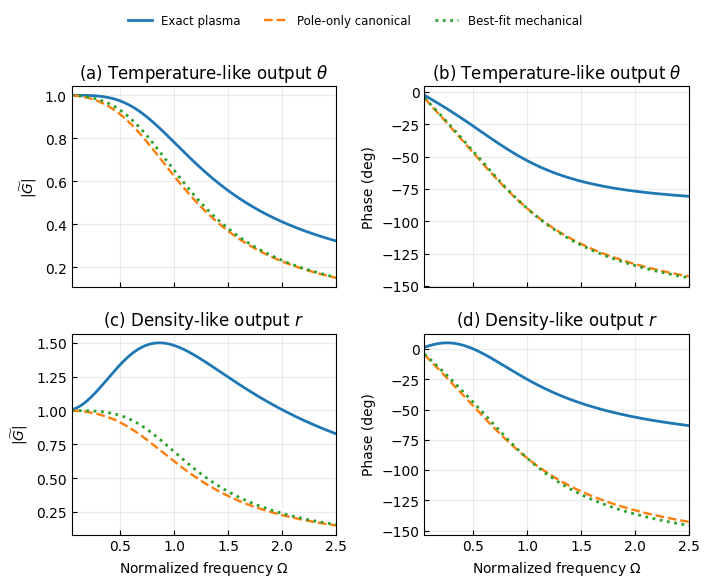

Saved:
  fig06_full_frf_comparison.pdf
  fig06_full_frf_comparison.png

Best-fit structural damping:
theta: 0.7689270431053749
r    : 0.7183985321911718

Exact Case 3D metrics:
output  zeta_star  complex_relative  mag_rms  phase_rms_deg  max_mag_error
 theta   0.768927          0.518770 0.140509      43.923094       0.180555
     r   0.718399          0.865279 0.682916      66.434701       0.851676


In [59]:
# ============================================================
# PUBLICATION FIGURE 6
# Full input-output cross-domain comparison
#
# Shows:
#   exact plasma input-output FRF
#   canonical pole-only plasma projection
#   best-fit structural displacement FRF
#
# Case 3C / 3D frozen evidence only.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Exact best-fit structural damping values from Case 3D
# ------------------------------------------------------------

exact_3d = case3d_results[
    case3d_results["model"] == "exact surrogate"
].copy()

zeta_star_theta = float(
    exact_3d[
        exact_3d["output"] == "theta"
    ]["zeta_star"].iloc[0]
)

zeta_star_r = float(
    exact_3d[
        exact_3d["output"] == "r"
    ]["zeta_star"].iloc[0]
)


# ------------------------------------------------------------
# Best-fit mechanical FRFs
# ------------------------------------------------------------

H_MECH_THETA_STAR = mechanical_normalized_frf(
    OMEGA_3C,
    zeta_star_theta
)

H_MECH_R_STAR = mechanical_normalized_frf(
    OMEGA_3C,
    zeta_star_r
)


# ------------------------------------------------------------
# Exact plasma responses
# ------------------------------------------------------------

H_THETA = exact_theta["Hn"]
H_R = exact_r["Hn"]


# ------------------------------------------------------------
# Magnitudes
# ------------------------------------------------------------

MAG_THETA = np.abs(H_THETA)
MAG_R = np.abs(H_R)

MAG_CANONICAL = np.abs(
    H_CANONICAL
)

MAG_MECH_THETA = np.abs(
    H_MECH_THETA_STAR
)

MAG_MECH_R = np.abs(
    H_MECH_R_STAR
)


# ------------------------------------------------------------
# Unwrapped phases in degrees
# ------------------------------------------------------------

PHASE_THETA = np.degrees(
    np.unwrap(
        np.angle(H_THETA)
    )
)

PHASE_R = np.degrees(
    np.unwrap(
        np.angle(H_R)
    )
)

PHASE_CANONICAL = np.degrees(
    np.unwrap(
        np.angle(H_CANONICAL)
    )
)

PHASE_MECH_THETA = np.degrees(
    np.unwrap(
        np.angle(H_MECH_THETA_STAR)
    )
)

PHASE_MECH_R = np.degrees(
    np.unwrap(
        np.angle(H_MECH_R_STAR)
    )
)


# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(7.2, 5.8),
    sharex=True
)

ax_a = axes[0, 0]
ax_b = axes[0, 1]
ax_c = axes[1, 0]
ax_d = axes[1, 1]


# ------------------------------------------------------------
# (a) theta amplitude
# ------------------------------------------------------------

ax_a.plot(
    OMEGA_3C,
    MAG_THETA,
    linewidth=2.0,
    label="Exact plasma"
)

ax_a.plot(
    OMEGA_3C,
    MAG_CANONICAL,
    "--",
    linewidth=1.7,
    label="Pole-only canonical"
)

ax_a.plot(
    OMEGA_3C,
    MAG_MECH_THETA,
    ":",
    linewidth=2.0,
    label="Best-fit mechanical"
)

ax_a.set_ylabel(
    r"$|\widetilde{G}|$"
)

ax_a.set_title(
    r"(a) Temperature-like output $\theta$"
)

ax_a.grid(
    True,
    alpha=0.25
)


# ------------------------------------------------------------
# (b) theta phase
# ------------------------------------------------------------

ax_b.plot(
    OMEGA_3C,
    PHASE_THETA,
    linewidth=2.0
)

ax_b.plot(
    OMEGA_3C,
    PHASE_CANONICAL,
    "--",
    linewidth=1.7
)

ax_b.plot(
    OMEGA_3C,
    PHASE_MECH_THETA,
    ":",
    linewidth=2.0
)

ax_b.set_ylabel(
    "Phase (deg)"
)

ax_b.set_title(
    r"(b) Temperature-like output $\theta$"
)

ax_b.grid(
    True,
    alpha=0.25
)


# ------------------------------------------------------------
# (c) r amplitude
# ------------------------------------------------------------

ax_c.plot(
    OMEGA_3C,
    MAG_R,
    linewidth=2.0
)

ax_c.plot(
    OMEGA_3C,
    MAG_CANONICAL,
    "--",
    linewidth=1.7
)

ax_c.plot(
    OMEGA_3C,
    MAG_MECH_R,
    ":",
    linewidth=2.0
)

ax_c.set_xlabel(
    r"Normalized frequency $\Omega$"
)

ax_c.set_ylabel(
    r"$|\widetilde{G}|$"
)

ax_c.set_title(
    r"(c) Density-like output $r$"
)

ax_c.grid(
    True,
    alpha=0.25
)


# ------------------------------------------------------------
# (d) r phase
# ------------------------------------------------------------

ax_d.plot(
    OMEGA_3C,
    PHASE_R,
    linewidth=2.0
)

ax_d.plot(
    OMEGA_3C,
    PHASE_CANONICAL,
    "--",
    linewidth=1.7
)

ax_d.plot(
    OMEGA_3C,
    PHASE_MECH_R,
    ":",
    linewidth=2.0
)

ax_d.set_xlabel(
    r"Normalized frequency $\Omega$"
)

ax_d.set_ylabel(
    "Phase (deg)"
)

ax_d.set_title(
    r"(d) Density-like output $r$"
)

ax_d.grid(
    True,
    alpha=0.25
)


# ------------------------------------------------------------
# Common axis formatting
# ------------------------------------------------------------

for ax in axes.flat:

    ax.set_xlim(
        CASE3C_PROTOCOL["Omega_min"],
        CASE3C_PROTOCOL["Omega_max"]
    )

    ax.tick_params(
        direction="in"
    )


# ------------------------------------------------------------
# Common legend
#
# Legend entries come only from panel (a).
# The optimized damping values differ for theta and r,
# so they are reported in the caption rather than the legend.
# ------------------------------------------------------------

handles, labels = (
    ax_a.get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.015),
    ncol=3,
    frameon=False,
    fontsize=8.5
)


# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

fig.tight_layout(
    rect=[0, 0, 1, 0.94]
)


# ------------------------------------------------------------
# Save publication versions
# ------------------------------------------------------------

fig.savefig(
    "fig06_full_frf_comparison.pdf",
    bbox_inches="tight"
)

fig.savefig(
    "fig06_full_frf_comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Audit output
# ------------------------------------------------------------

print("Saved:")
print("  fig06_full_frf_comparison.pdf")
print("  fig06_full_frf_comparison.png")

print("\nBest-fit structural damping:")
print(
    "theta:",
    zeta_star_theta
)

print(
    "r    :",
    zeta_star_r
)

print("\nExact Case 3D metrics:")

print(
    exact_3d[
        [
            "output",
            "zeta_star",
            "complex_relative",
            "mag_rms",
            "phase_rms_deg",
            "max_mag_error"
        ]
    ].to_string(
        index=False
    )
)

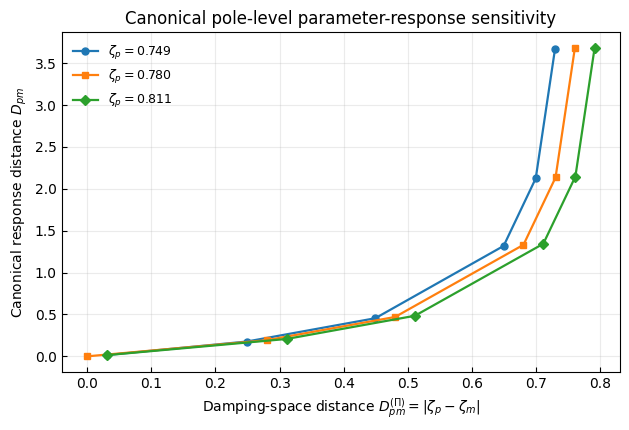

Saved:
  fig06_canonical_parameter_response.pdf
  fig06_canonical_parameter_response.png

Canonical sensitivity:
Unique comparisons = 18
Plasma damping levels = [np.float64(0.7491131910873989), np.float64(0.7800088823828552), np.float64(0.8109045736783114)]
Pearson r = 0.8166116518960201
Spearman rho = 0.9855521155830752


In [60]:
# ============================================================
# PUBLICATION FIGURE 6
# Canonical pole-level parameter-response sensitivity
#
# Purpose:
#   Show the relationship between damping-space distance
#   and canonical response-space distance only.
#
# This is a secondary diagnostic figure.
# It does NOT represent full input-output correspondence.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Source data
# ------------------------------------------------------------

df = case3b_unique.copy()

required_cols = [
    "zeta_p",
    "zeta_m",
    "D_parameter",
    "D_response",
]

missing = [
    c for c in required_cols
    if c not in df.columns
]

if missing:
    raise RuntimeError(
        f"Missing required columns: {missing}"
    )


# Sort for clean curve rendering
df = df.sort_values(
    [
        "zeta_p",
        "D_parameter"
    ]
)


# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(6.4, 4.4)
)


# ------------------------------------------------------------
# Plot one curve per plasma damping level
# ------------------------------------------------------------

markers = [
    "o",
    "s",
    "D",
]

for marker, zeta_p in zip(
    markers,
    sorted(
        df["zeta_p"].unique()
    )
):

    d = df[
        np.isclose(
            df["zeta_p"],
            zeta_p
        )
    ].sort_values(
        "D_parameter"
    )

    ax.plot(
        d["D_parameter"],
        d["D_response"],
        marker=marker,
        linewidth=1.6,
        markersize=5,
        label=(
            rf"$\zeta_p={zeta_p:.3f}$"
        )
    )


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax.set_xlabel(
    r"Damping-space distance "
    r"$D_{pm}^{(\Pi)}=|\zeta_p-\zeta_m|$"
)

ax.set_ylabel(
    r"Canonical response distance $D_{pm}$"
)

ax.set_title(
    "Canonical pole-level parameter-response sensitivity"
)

ax.grid(
    True,
    alpha=0.25
)

ax.tick_params(
    direction="in"
)

ax.legend(
    frameon=False,
    fontsize=9
)

fig.tight_layout()


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

fig.savefig(
    "fig06_canonical_parameter_response.pdf",
    bbox_inches="tight"
)

fig.savefig(
    "fig06_canonical_parameter_response.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Audit output
# ------------------------------------------------------------

from scipy.stats import pearsonr, spearmanr

r_global = pearsonr(
    df["D_parameter"],
    df["D_response"]
).statistic

rho_global = spearmanr(
    df["D_parameter"],
    df["D_response"]
).statistic


print("Saved:")
print("  fig06_canonical_parameter_response.pdf")
print("  fig06_canonical_parameter_response.png")

print("\nCanonical sensitivity:")
print(
    "Unique comparisons =",
    len(df)
)

print(
    "Plasma damping levels =",
    sorted(
        df["zeta_p"].unique()
    )
)

print(
    "Pearson r =",
    r_global
)

print(
    "Spearman rho =",
    rho_global
)